SAHITYA - PAPER 1
HEART DISEASE PREDICTION USING MACHINE LEARNING

Dataset downloaded successfully from UCI.

DATASET INFORMATION

Dataset Shape:
(303, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    -----

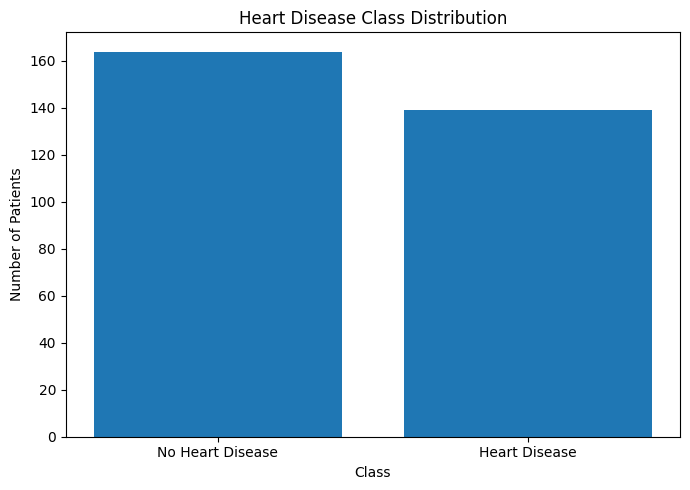

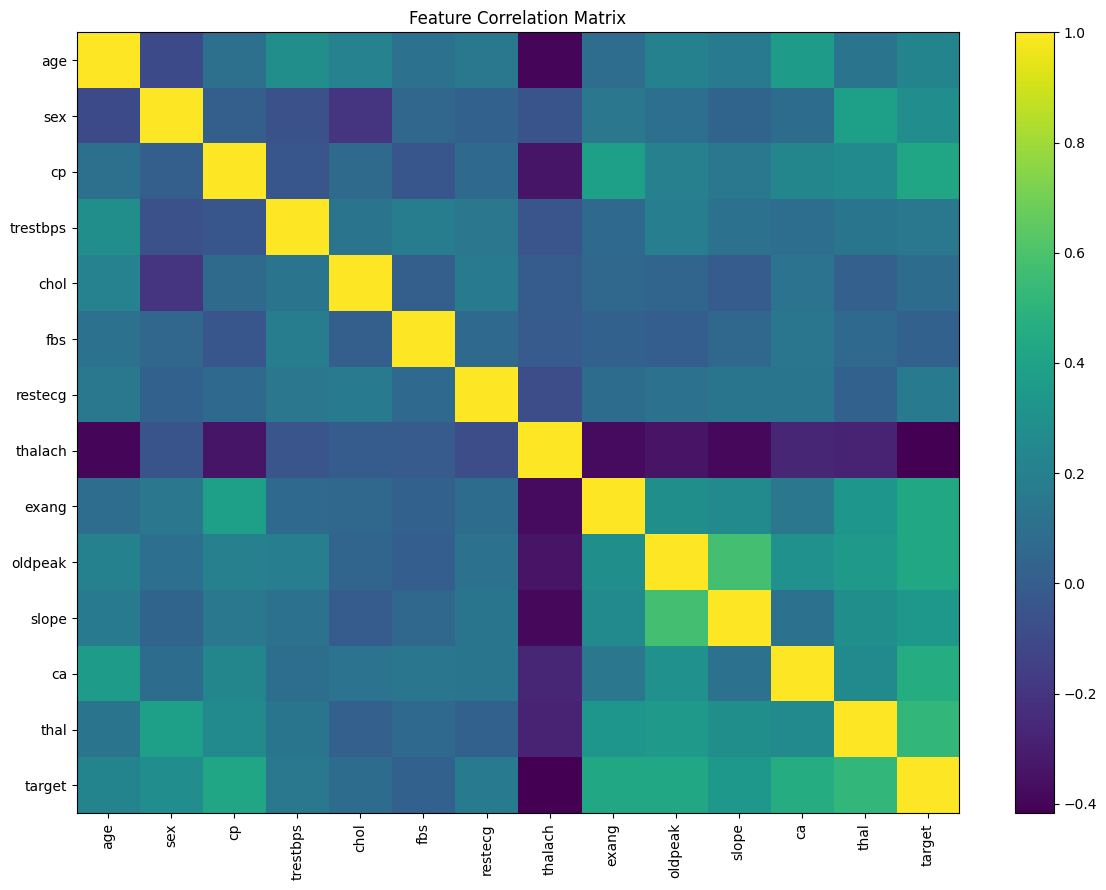


Feature Matrix Shape: (303, 13)
Target Shape: (303,)

Training Samples: 242
Testing Samples : 61

Feature scaling completed successfully.

MODEL TRAINING AND TESTING


MODEL: Logistic Regression
Accuracy  : 86.89%
Precision : 81.25%
Recall    : 92.86%
F1 Score  : 86.67%
ROC-AUC   : 0.9513

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.82      0.87        33
   Heart Disease       0.81      0.93      0.87        28

        accuracy                           0.87        61
       macro avg       0.87      0.87      0.87        61
    weighted avg       0.88      0.87      0.87        61



MODEL: Naive Bayes
Accuracy  : 86.89%
Precision : 79.41%
Recall    : 96.43%
F1 Score  : 87.10%
ROC-AUC   : 0.9524

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.96      0.79      0.87        33
   Heart Disease       0.79      0.96      0.87        28

        accuracy  

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9578
1,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
2,Naive Bayes,0.8689,0.7941,0.9643,0.8710,0.9524
3,SVM,0.8525,0.8065,0.8929,0.8475,0.9437
4,Decision Tree,0.8033,0.7500,0.8571,0.8000,0.8074


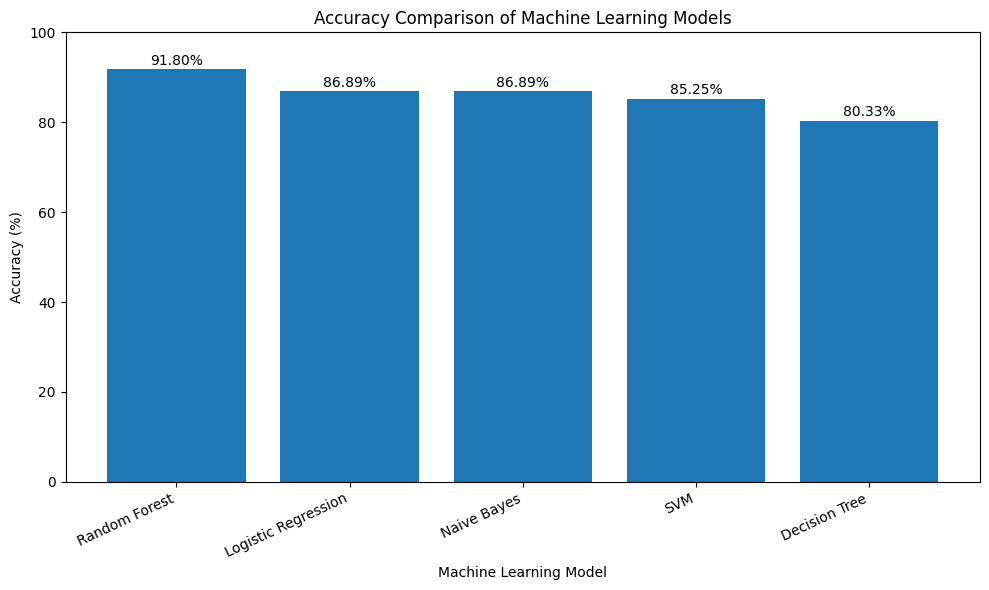


CONFUSION MATRICES


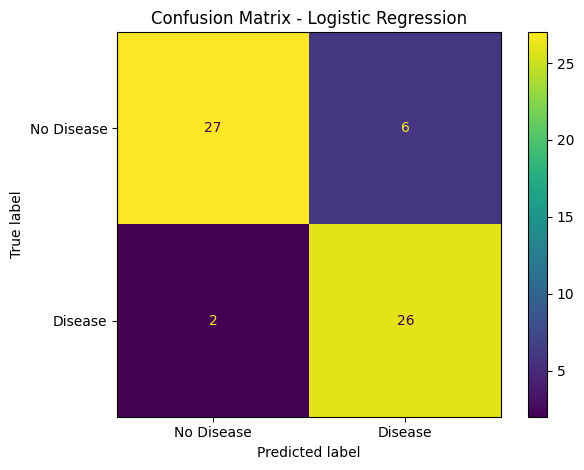

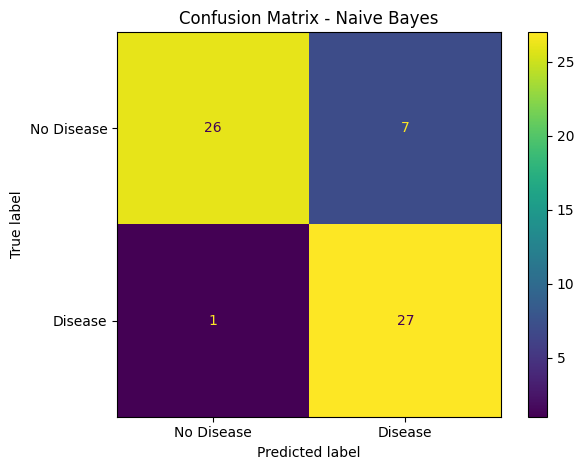

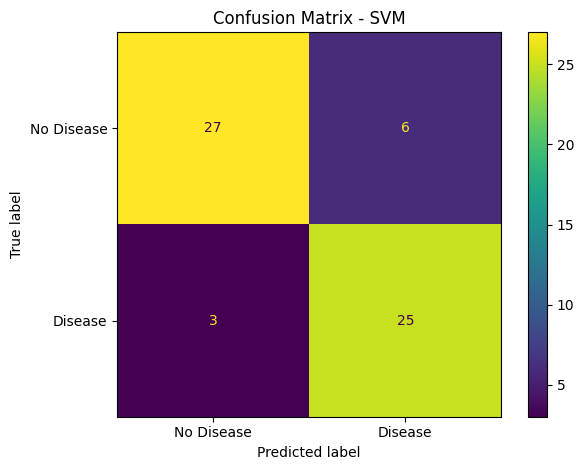

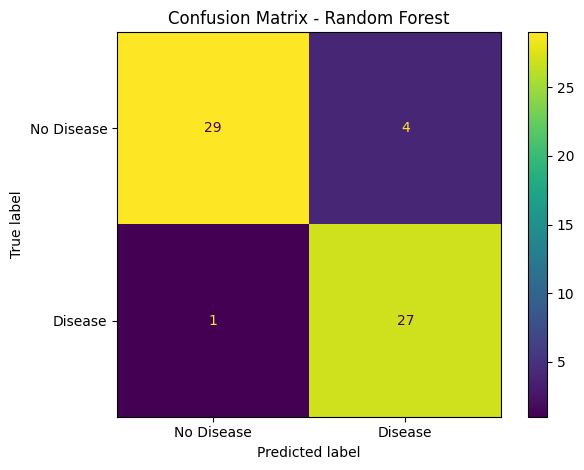

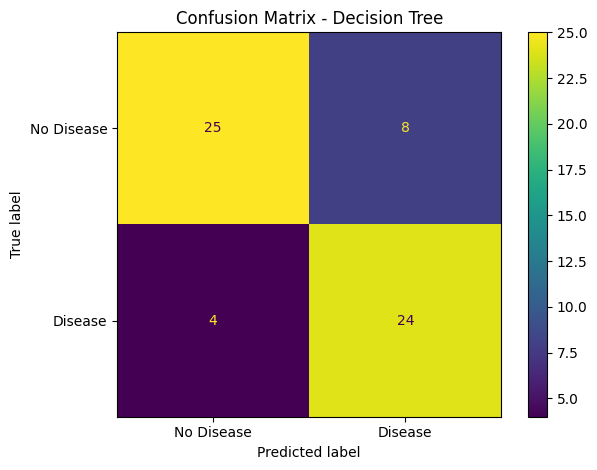

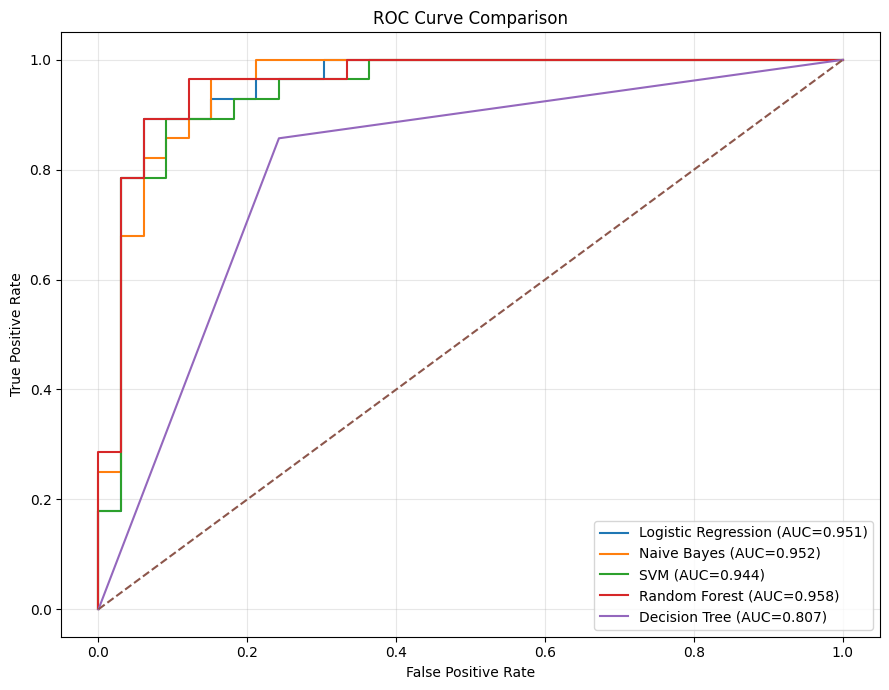

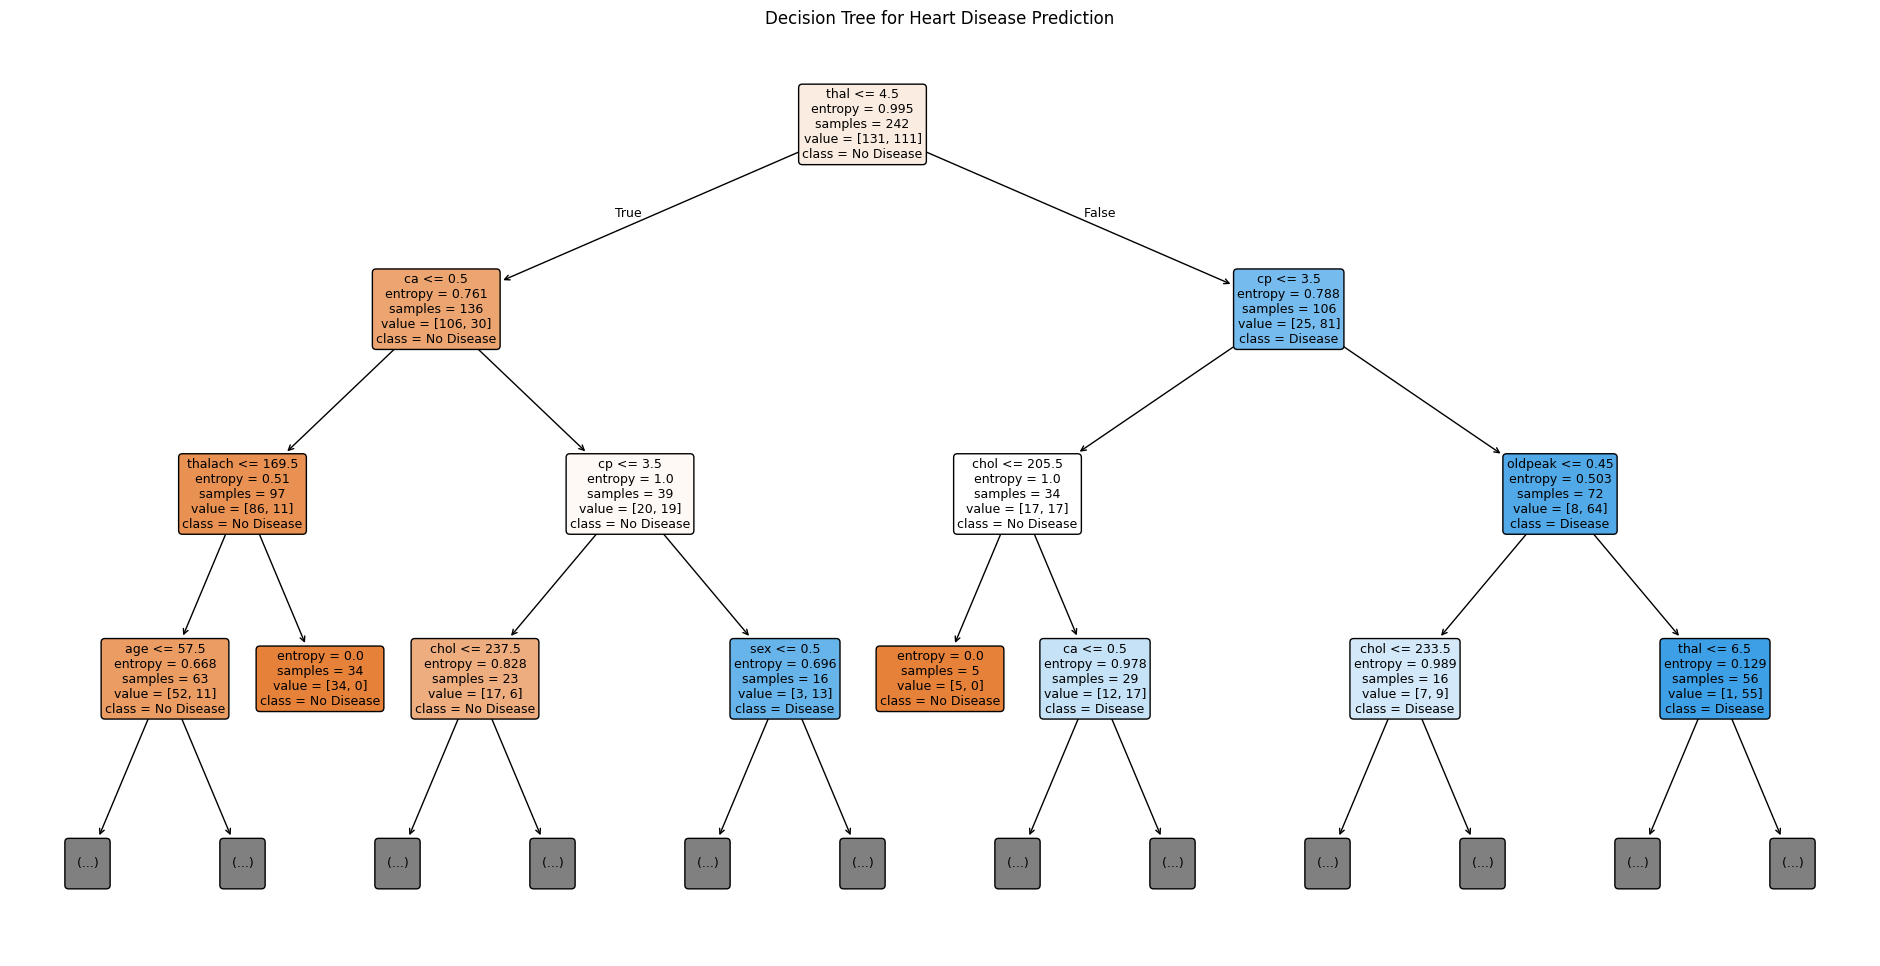



RANDOM FOREST FEATURE IMPORTANCE
 Feature  Importance
    thal    0.136390
 thalach    0.122866
      cp    0.119751
      ca    0.107645
 oldpeak    0.091360
     age    0.091066
    chol    0.085320
trestbps    0.077561
   exang    0.052788
   slope    0.042666
     sex    0.038878
 restecg    0.021145
     fbs    0.012563


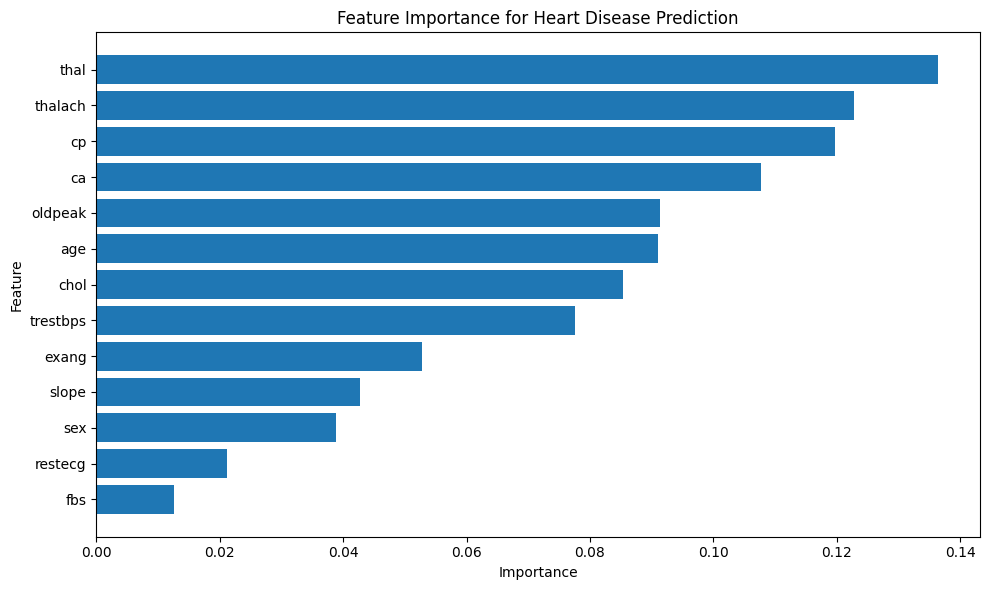



BEST MODEL
Best Performing Model: Random Forest
Test Accuracy: 91.80%


DECISION TREE PERFORMANCE
Accuracy  : 80.33%
Precision : 75.00%
Recall    : 85.71%
F1 Score  : 80.00%
ROC-AUC   : 0.8074


SAMPLE PATIENT PREDICTION
Prediction: NO HEART DISEASE

NOTE: This prediction is for academic demonstration only.


SAHITYA PAPER 1 - FINAL SUMMARY

Dataset:
UCI Cleveland Heart Disease Dataset

Problem:
Binary classification of patients into:
0 = No Heart Disease
1 = Heart Disease

Machine Learning Algorithms Implemented:
1. Logistic Regression
2. Naive Bayes
3. Support Vector Machine
4. Random Forest
5. Decision Tree

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

The program compares all five machine-learning algorithms and
automatically identifies the best-performing model on the current
train/test split.

The reference paper/table reports Decision Tree as its strongest
model with 98.54% accuracy. The accuracy produced by this note

In [1]:
# ================================================================
# SAHITYA - IIT PROJECT
# PAPER 1
# Heart Disease Prediction using Machine Learning Techniques
#
# Models:
# 1. Logistic Regression
# 2. Naive Bayes
# 3. Support Vector Machine (SVM)
# 4. Random Forest
# 5. Decision Tree
#
# Dataset: UCI Heart Disease Dataset
# ================================================================


# ================================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

print("=" * 70)
print("SAHITYA - PAPER 1")
print("HEART DISEASE PREDICTION USING MACHINE LEARNING")
print("=" * 70)


# ================================================================
# STEP 2: LOAD UCI HEART DISEASE DATASET
# ================================================================
# Cleveland Heart Disease dataset from the UCI repository.
# The raw dataset has 14 commonly used columns.

url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/heart-disease/processed.cleveland.data"
)

column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

try:
    df = pd.read_csv(
        url,
        names=column_names,
        na_values="?"
    )

    print("\nDataset downloaded successfully from UCI.")

except Exception as e:

    print("\nCould not download dataset.")
    print("Error:", e)

    print("\nCreating a small demonstration dataset instead.")

    # Backup only so the notebook does not crash if UCI is temporarily
    # unavailable. For actual project results, use the UCI dataset.

    from sklearn.datasets import make_classification

    X_demo, y_demo = make_classification(
        n_samples=303,
        n_features=13,
        n_informative=9,
        n_redundant=2,
        n_classes=2,
        random_state=42
    )

    df = pd.DataFrame(
        X_demo,
        columns=column_names[:-1]
    )

    df["target"] = y_demo


# ================================================================
# STEP 3: DISPLAY DATASET INFORMATION
# ================================================================

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


# ================================================================
# STEP 4: DATA CLEANING
# ================================================================

print("\n" + "=" * 70)
print("DATA PREPROCESSING")
print("=" * 70)

# Convert every column to numeric where possible
for column in df.columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")


# Fill missing numerical values using the median
for column in df.columns:

    if df[column].isnull().sum() > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(median_value)


print("\nMissing values after cleaning:")
print(df.isnull().sum())


# ================================================================
# STEP 5: CONVERT TARGET INTO BINARY CLASSIFICATION
# ================================================================
# Original Cleveland target:
#
# 0     = No heart disease
# 1-4   = Presence of heart disease
#
# Therefore:
#
# 0 -> No Disease
# 1 -> Heart Disease

df["target"] = (df["target"] > 0).astype(int)


print("\nTarget Distribution:")
print(df["target"].value_counts())

print("\nTarget Percentage:")
print(df["target"].value_counts(normalize=True) * 100)


# ================================================================
# STEP 6: BASIC STATISTICAL INFORMATION
# ================================================================

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

print(df.describe().round(2))


# ================================================================
# STEP 7: TARGET CLASS DISTRIBUTION GRAPH
# ================================================================

class_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    class_counts.values
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()


# ================================================================
# STEP 8: CORRELATION MATRIX
# ================================================================

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()


# ================================================================
# STEP 9: SEPARATE FEATURES AND TARGET
# ================================================================

X = df.drop("target", axis=1)

y = df["target"]


print("\nFeature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)


# ================================================================
# STEP 10: TRAIN-TEST SPLIT
# ================================================================
# 80% training
# 20% testing
#
# stratify=y maintains the class distribution.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Samples:", len(X_train))

print("Testing Samples :", len(X_test))


# ================================================================
# STEP 11: FEATURE SCALING
# ================================================================
# Scaling is particularly important for:
#
# Logistic Regression
# SVM
#
# Tree models do not require scaling, so we keep both versions.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print("\nFeature scaling completed successfully.")


# ================================================================
# STEP 12: CREATE MACHINE LEARNING MODELS
# ================================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            criterion="entropy",
            random_state=42
        )
}


# ================================================================
# STEP 13: TRAIN AND EVALUATE ALL FIVE MODELS
# ================================================================

results = []

predictions = {}

probabilities = {}


print("\n" + "=" * 70)
print("MODEL TRAINING AND TESTING")
print("=" * 70)


for model_name, model in models.items():

    print("\n")
    print("=" * 70)
    print("MODEL:", model_name)
    print("=" * 70)


    # ------------------------------------------------------------
    # Select scaled/unscaled data
    # ------------------------------------------------------------

    if model_name in [
        "Logistic Regression",
        "Naive Bayes",
        "SVM"
    ]:

        train_data = X_train_scaled
        test_data = X_test_scaled

    else:

        train_data = X_train
        test_data = X_test


    # ------------------------------------------------------------
    # Train model
    # ------------------------------------------------------------

    model.fit(
        train_data,
        y_train
    )


    # ------------------------------------------------------------
    # Prediction
    # ------------------------------------------------------------

    y_pred = model.predict(test_data)

    predictions[model_name] = y_pred


    # ------------------------------------------------------------
    # Probability prediction
    # ------------------------------------------------------------

    if hasattr(model, "predict_proba"):

        y_probability = model.predict_proba(test_data)[:, 1]

    elif hasattr(model, "decision_function"):

        y_probability = model.decision_function(test_data)

    else:

        y_probability = y_pred


    probabilities[model_name] = y_probability


    # ------------------------------------------------------------
    # Evaluation Metrics
    # ------------------------------------------------------------

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )


    # ------------------------------------------------------------
    # Store results
    # ------------------------------------------------------------

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": auc
    })


    # ------------------------------------------------------------
    # Display model results
    # ------------------------------------------------------------

    print(
        f"Accuracy  : {accuracy * 100:.2f}%"
    )

    print(
        f"Precision : {precision * 100:.2f}%"
    )

    print(
        f"Recall    : {recall * 100:.2f}%"
    )

    print(
        f"F1 Score  : {f1 * 100:.2f}%"
    )

    print(
        f"ROC-AUC   : {auc:.4f}"
    )


    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                "No Heart Disease",
                "Heart Disease"
            ],
            zero_division=0
        )
    )


# ================================================================
# STEP 14: MODEL COMPARISON TABLE
# ================================================================

results_df = pd.DataFrame(results)


results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

display(
    results_df.style.format({

        "Accuracy": "{:.4f}",

        "Precision": "{:.4f}",

        "Recall": "{:.4f}",

        "F1 Score": "{:.4f}",

        "ROC-AUC": "{:.4f}"
    })
)


# ================================================================
# STEP 15: ACCURACY COMPARISON GRAPH
# ================================================================

plt.figure(figsize=(10, 6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"] * 100
)

plt.title(
    "Accuracy Comparison of Machine Learning Models"
)

plt.xlabel(
    "Machine Learning Model"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.ylim(
    0,
    100
)


for i, value in enumerate(results_df["Accuracy"] * 100):

    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )


plt.tight_layout()

plt.show()


# ================================================================
# STEP 16: CONFUSION MATRICES
# ================================================================

print("\n" + "=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)


for model_name in models.keys():

    y_pred = predictions[model_name]

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "No Disease",
            "Disease"
        ]
    )

    disp.plot()

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.tight_layout()

    plt.show()


# ================================================================
# STEP 17: ROC CURVES
# ================================================================

plt.figure(figsize=(9, 7))


for model_name in models.keys():

    y_probability = probabilities[model_name]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_probability
    )

    auc_value = roc_auc_score(
        y_test,
        y_probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc_value:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve Comparison"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ================================================================
# STEP 18: DECISION TREE VISUALIZATION
# ================================================================

decision_tree = models["Decision Tree"]


plt.figure(
    figsize=(24, 12)
)

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=[
        "No Disease",
        "Disease"
    ],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title(
    "Decision Tree for Heart Disease Prediction"
)

plt.show()


# ================================================================
# STEP 19: RANDOM FOREST FEATURE IMPORTANCE
# ================================================================

random_forest = models["Random Forest"]


feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        random_forest.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


print("\n")
print("=" * 70)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 70)

print(
    feature_importance.to_string(
        index=False
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Feature Importance for Heart Disease Prediction"
)

plt.tight_layout()

plt.show()


# ================================================================
# STEP 20: FIND BEST MODEL
# ================================================================

best_row = results_df.iloc[0]

best_model_name = best_row["Model"]

best_accuracy = best_row["Accuracy"]


print("\n")
print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "Best Performing Model:",
    best_model_name
)

print(
    f"Test Accuracy: {best_accuracy * 100:.2f}%"
)


# ================================================================
# STEP 21: DECISION TREE RESULT SPECIFICALLY
# ================================================================

dt_result = results_df[
    results_df["Model"] == "Decision Tree"
].iloc[0]


print("\n")
print("=" * 70)
print("DECISION TREE PERFORMANCE")
print("=" * 70)

print(
    f"Accuracy  : {dt_result['Accuracy'] * 100:.2f}%"
)

print(
    f"Precision : {dt_result['Precision'] * 100:.2f}%"
)

print(
    f"Recall    : {dt_result['Recall'] * 100:.2f}%"
)

print(
    f"F1 Score  : {dt_result['F1 Score'] * 100:.2f}%"
)

print(
    f"ROC-AUC   : {dt_result['ROC-AUC']:.4f}"
)


# ================================================================
# STEP 22: SAMPLE PATIENT PREDICTION
# ================================================================
# IMPORTANT:
# This is only an ML demonstration.
# It must NOT be used for real medical diagnosis.

sample_patient = pd.DataFrame(
    [[
        55,     # age
        1,      # sex
        2,      # chest pain type
        140,    # resting blood pressure
        250,    # cholesterol
        0,      # fasting blood sugar
        1,      # resting ECG
        150,    # maximum heart rate
        0,      # exercise induced angina
        1.5,    # oldpeak
        1,      # slope
        0,      # number of major vessels
        3       # thal
    ]],
    columns=X.columns
)


patient_prediction = decision_tree.predict(
    sample_patient
)[0]


print("\n")
print("=" * 70)
print("SAMPLE PATIENT PREDICTION")
print("=" * 70)


if patient_prediction == 0:

    print(
        "Prediction: NO HEART DISEASE"
    )

else:

    print(
        "Prediction: HEART DISEASE"
    )


print(
    "\nNOTE: This prediction is for academic demonstration only."
)


# ================================================================
# STEP 23: FINAL PROJECT SUMMARY
# ================================================================

print("\n")
print("=" * 80)
print("SAHITYA PAPER 1 - FINAL SUMMARY")
print("=" * 80)

print("""
Dataset:
UCI Cleveland Heart Disease Dataset

Problem:
Binary classification of patients into:
0 = No Heart Disease
1 = Heart Disease

Machine Learning Algorithms Implemented:
1. Logistic Regression
2. Naive Bayes
3. Support Vector Machine
4. Random Forest
5. Decision Tree

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

The program compares all five machine-learning algorithms and
automatically identifies the best-performing model on the current
train/test split.

The reference paper/table reports Decision Tree as its strongest
model with 98.54% accuracy. The accuracy produced by this notebook
does not have to be exactly 98.54%, because results depend on the
exact dataset version, preprocessing, train/test split, random seed,
and model hyperparameters used in the experiment.

This implementation is intended for academic/research demonstration
and not for clinical diagnosis.
""")

print("=" * 80)
print("PAPER 1 EXECUTION COMPLETED SUCCESSFULLY")
print("=" * 80)

SAHITYA - PAPER 2
MACHINE LEARNING PREDICTION IN CARDIOVASCULAR DISEASES
META-ANALYSIS INSPIRED IMPLEMENTATION

Dataset downloaded successfully from UCI.


DATASET INFORMATION

Dataset Shape:
(303, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column  

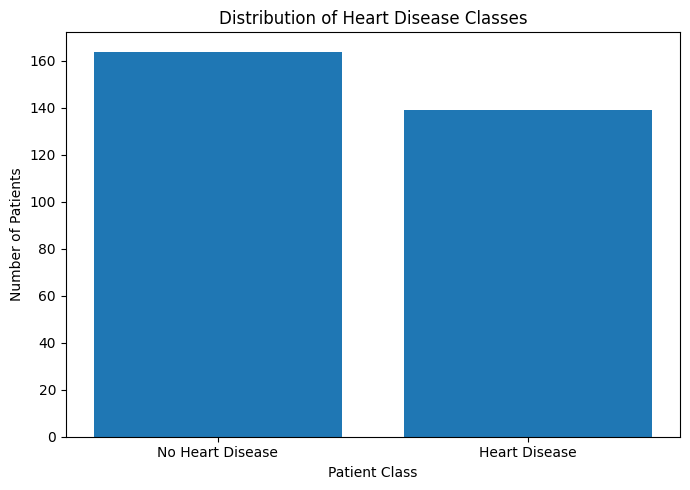

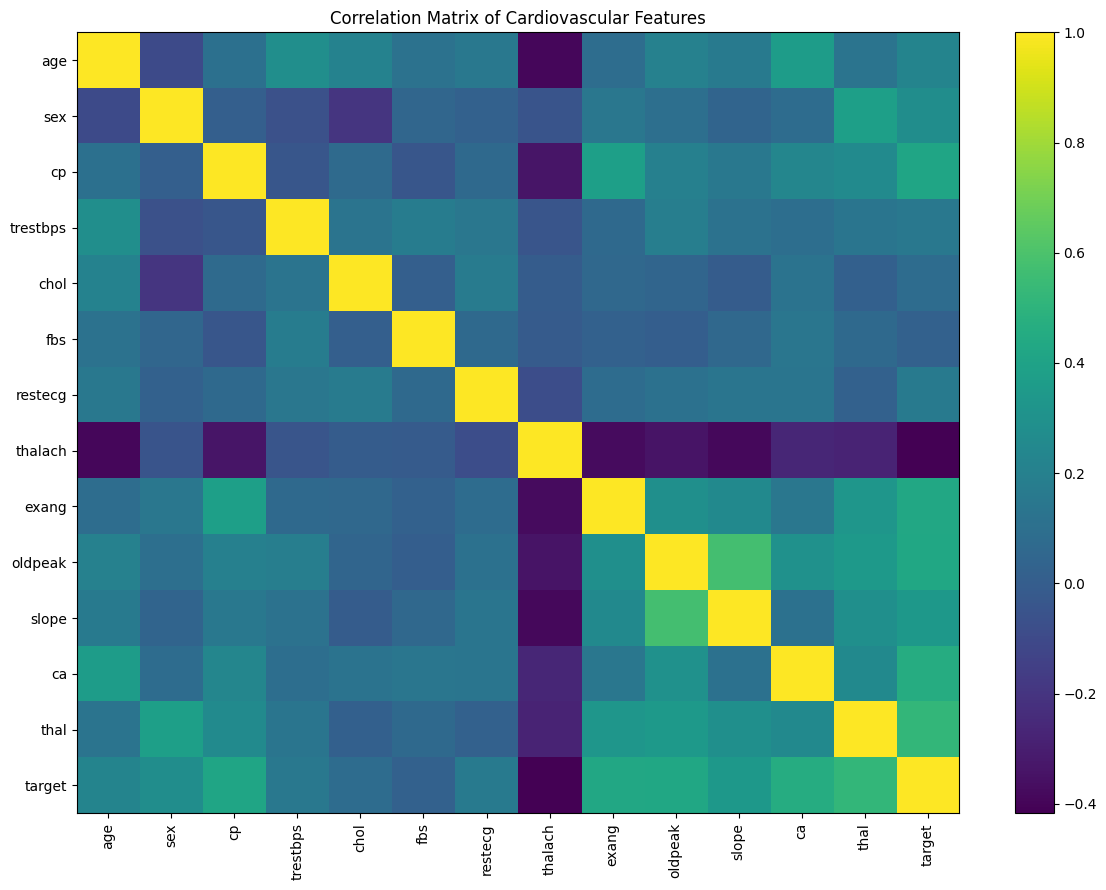


Feature Matrix Shape: (303, 13)
Target Shape: (303,)

Training Samples: 242
Testing Samples : 61

XGBoost successfully loaded.


5-FOLD STRATIFIED CROSS-VALIDATION

Evaluating: SVM
Accuracy : 83.81% +/- 3.90%
Precision: 0.8526
Recall   : 0.7839
F1 Score : 0.8153
ROC-AUC  : 0.8975 +/- 0.0253

Evaluating: Random Forest
Accuracy : 84.82% +/- 3.34%
Precision: 0.8570
Recall   : 0.8056
F1 Score : 0.8290
ROC-AUC  : 0.9089 +/- 0.0232

Evaluating: Gradient Boosting
Accuracy : 81.49% +/- 4.48%
Precision: 0.8059
Recall   : 0.7831
F1 Score : 0.7928
ROC-AUC  : 0.8992 +/- 0.0198

Evaluating: AdaBoost
Accuracy : 82.84% +/- 2.00%
Precision: 0.8393
Recall   : 0.7765
F1 Score : 0.8051
ROC-AUC  : 0.9071 +/- 0.0198

Evaluating: Neural Network
Accuracy : 80.51% +/- 3.27%
Precision: 0.8107
Recall   : 0.7630
F1 Score : 0.7824
ROC-AUC  : 0.8755 +/- 0.0220

Evaluating: XGBoost
Accuracy : 82.51% +/- 1.98%
Precision: 0.8218
Recall   : 0.7981
F1 Score : 0.8070
ROC-AUC  : 0.8962 +/- 0.0145


CROSS-VALIDATION MODE

,Model,CV Accuracy,Accuracy Std,CV Precision,CV Recall,CV F1,CV ROC-AUC,AUC Std
0,Random Forest,0.8482,0.0334,0.8570,0.8056,0.8290,0.9089,0.0232
1,AdaBoost,0.8284,0.0200,0.8393,0.7765,0.8051,0.9071,0.0198
2,Gradient Boosting,0.8149,0.0448,0.8059,0.7831,0.7928,0.8992,0.0198
3,SVM,0.8381,0.0390,0.8526,0.7839,0.8153,0.8975,0.0253
4,XGBoost,0.8251,0.0198,0.8218,0.7981,0.8070,0.8962,0.0145
5,Neural Network,0.8051,0.0327,0.8107,0.7630,0.7824,0.8755,0.0220




TRAIN-TEST EVALUATION


--------------------------------------------------------------------------------
MODEL: SVM
--------------------------------------------------------------------------------
Accuracy  : 85.25%
Precision : 80.65%
Recall    : 89.29%
F1 Score  : 84.75%
ROC-AUC   : 0.9437

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.90      0.82      0.86        33
   Heart Disease       0.81      0.89      0.85        28

        accuracy                           0.85        61
       macro avg       0.85      0.86      0.85        61
    weighted avg       0.86      0.85      0.85        61



--------------------------------------------------------------------------------
MODEL: Random Forest
--------------------------------------------------------------------------------
Accuracy  : 91.80%
Precision : 87.10%
Recall    : 96.43%
F1 Score  : 91.53%
ROC-AUC   : 0.9583

Classification Report:
                  precision

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,AdaBoost,0.9016,0.8667,0.9286,0.8966,0.9784
1,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9583
2,Gradient Boosting,0.9016,0.8667,0.9286,0.8966,0.9578
3,XGBoost,0.8852,0.8182,0.9643,0.8852,0.9567
4,SVM,0.8525,0.8065,0.8929,0.8475,0.9437
5,Neural Network,0.8525,0.7714,0.9643,0.8571,0.9340


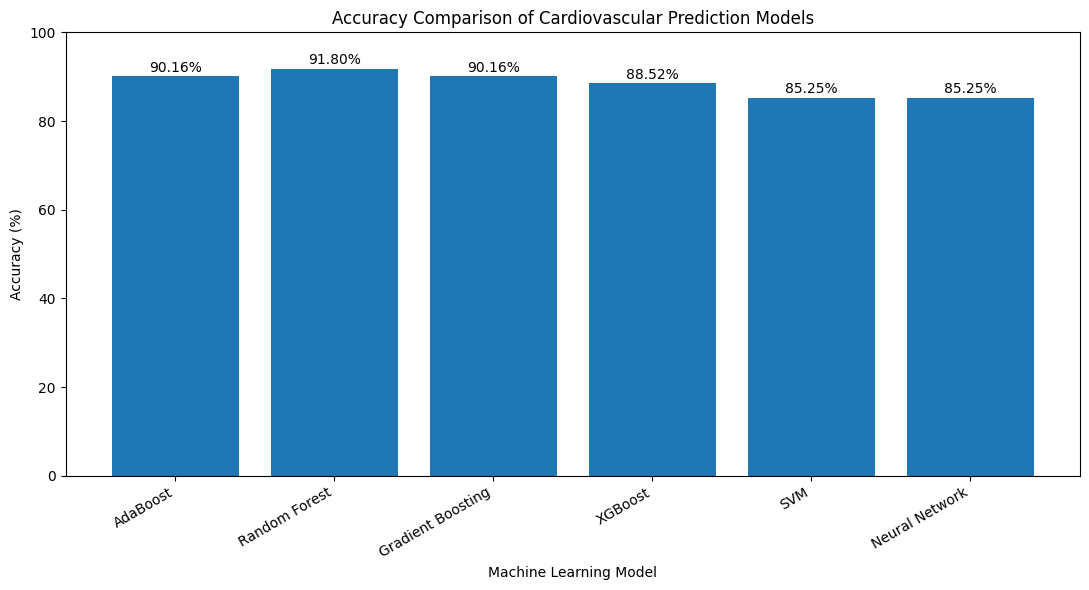

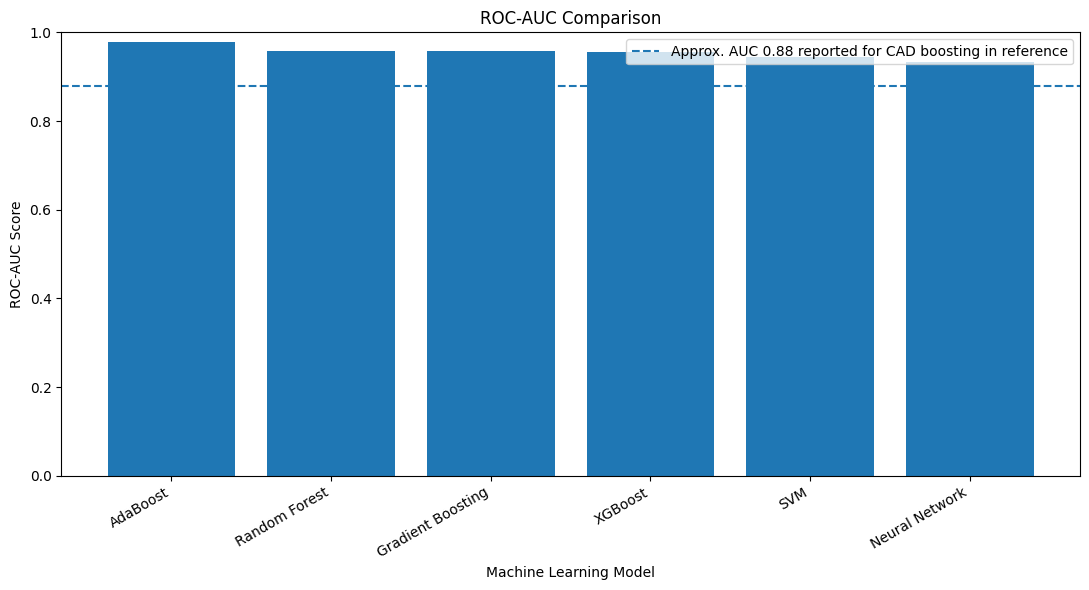

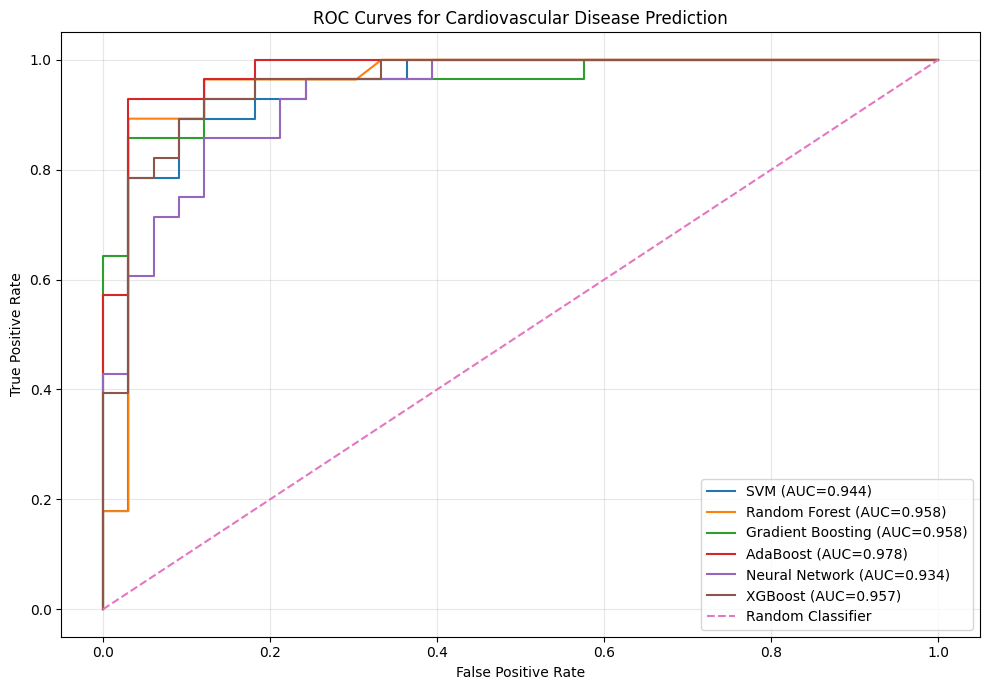



CONFUSION MATRICES


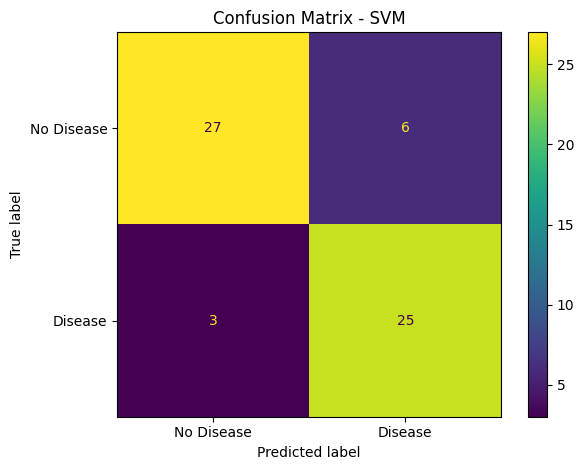

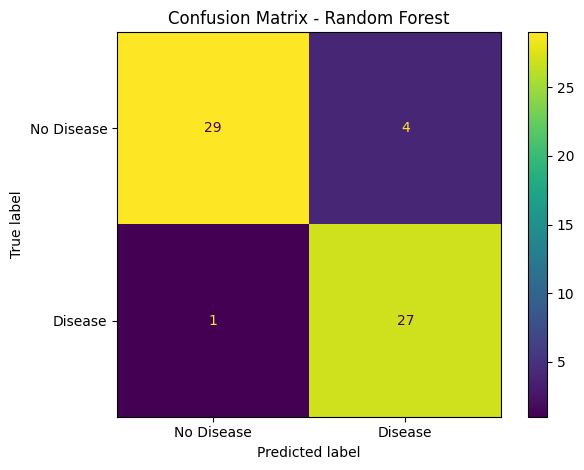

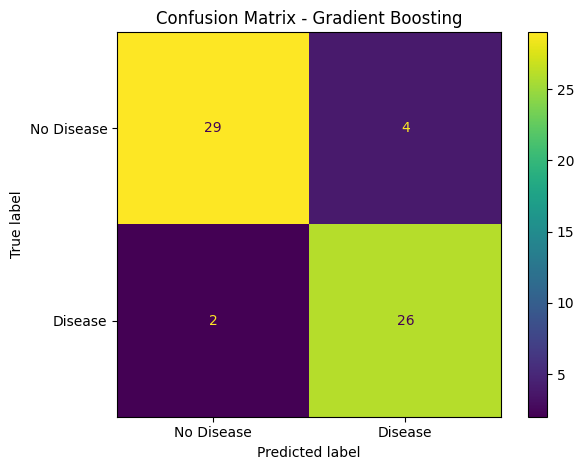

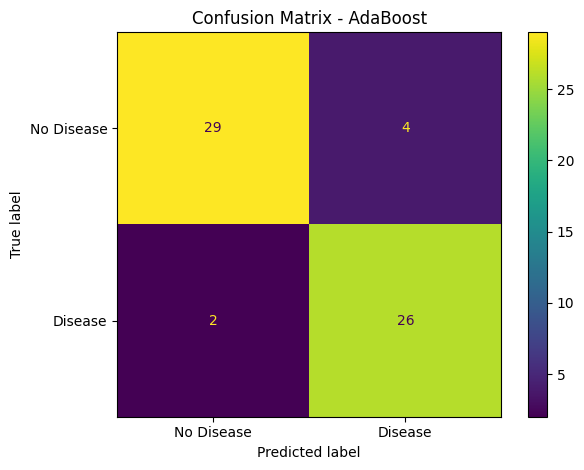

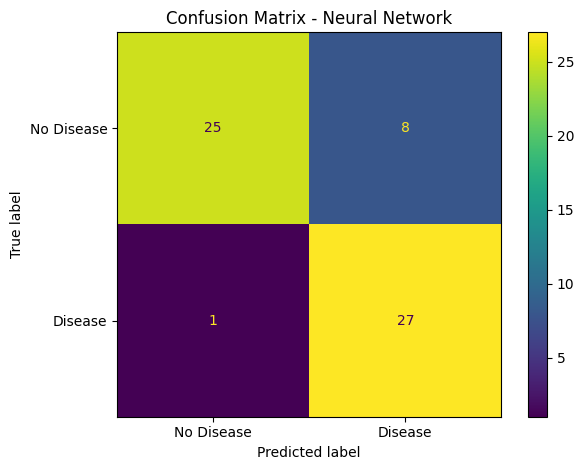

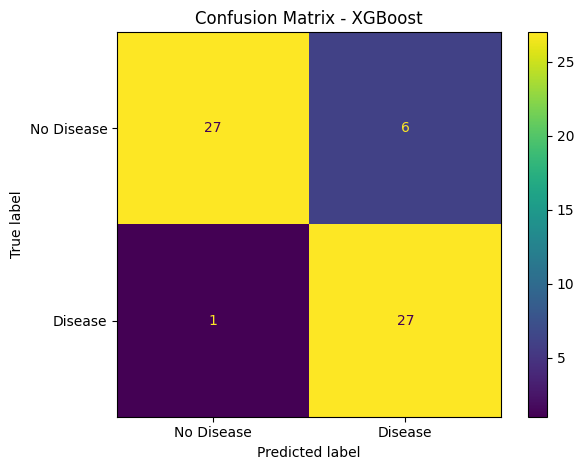

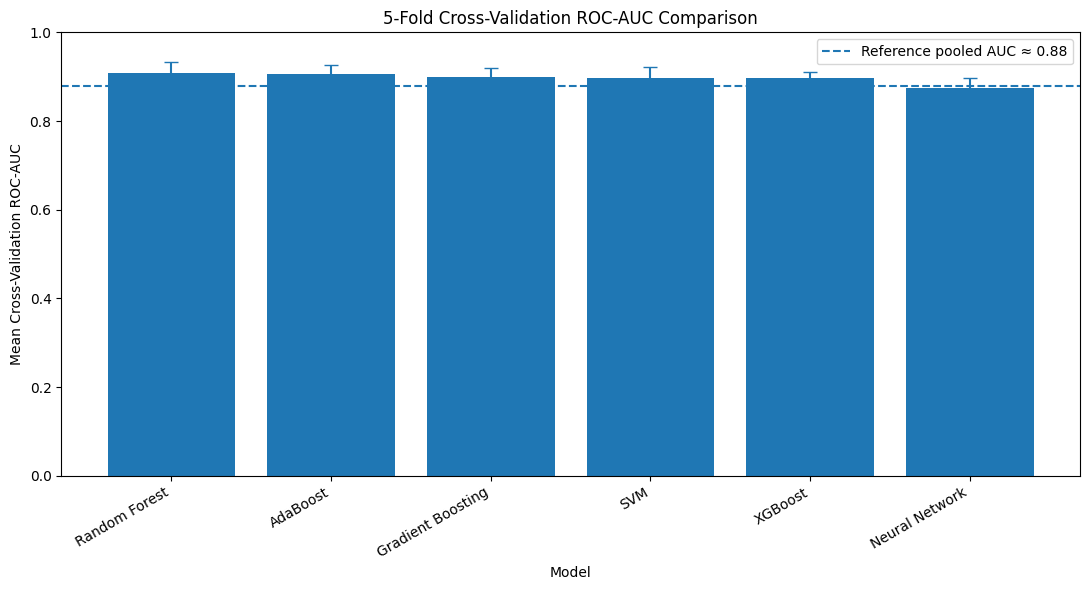



RANDOM FOREST FEATURE IMPORTANCE
 Feature  Importance
    thal    0.130714
 thalach    0.120942
      cp    0.118695
      ca    0.109750
     age    0.096474
 oldpeak    0.091358
    chol    0.084957
trestbps    0.078302
   exang    0.050887
   slope    0.044035
     sex    0.040286
 restecg    0.022454
     fbs    0.011147


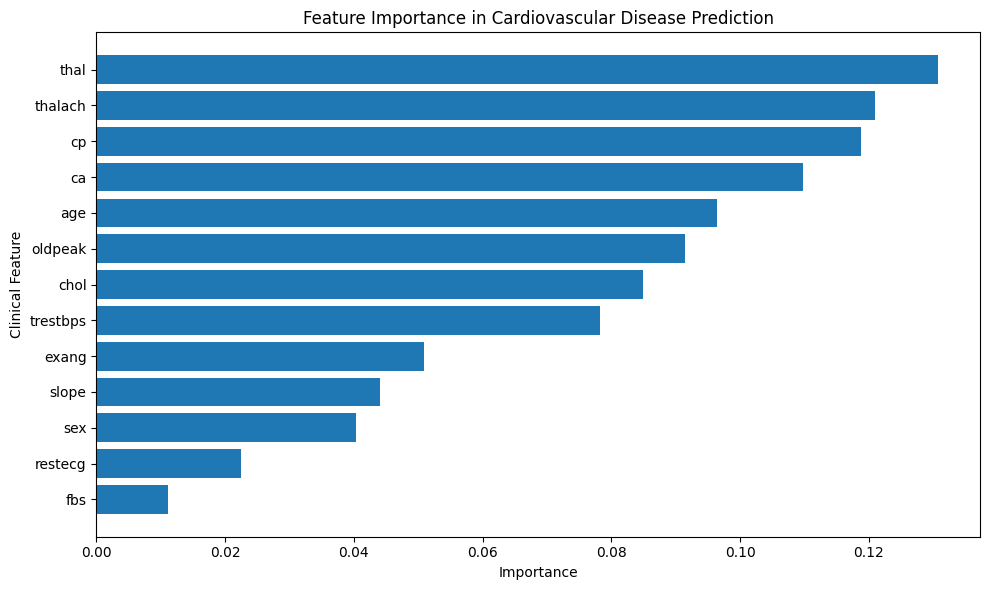



BEST CROSS-VALIDATION MODEL
Best Model: Random Forest
Mean CV Accuracy: 84.82%
Mean CV ROC-AUC: 0.9089


BEST TEST-SET MODEL
Best Model: AdaBoost
Accuracy: 90.16%
ROC-AUC: 0.9784


SAMPLE PATIENT PREDICTION
Prediction: NO HEART DISEASE

Academic demonstration only - not for clinical diagnosis.


PAPER 2 - META-ANALYSIS STYLE SUMMARY

Algorithms Evaluated:
---------------------
1. Support Vector Machine (SVM)
2. Random Forest
3. Gradient Boosting
4. AdaBoost
5. Neural Network
6. XGBoost (when available)


Evaluation Strategy:
--------------------
5-Fold Stratified Cross-Validation

Metrics:
--------
Accuracy
Precision
Recall
F1 Score
ROC-AUC


Best Cross-Validation Model:
----------------------------
Random Forest

Mean Accuracy:
84.82%

Mean ROC-AUC:
0.9089


Best Test Model:
----------------
AdaBoost

Test Accuracy:
90.16%

Test ROC-AUC:
0.9784


Reference Paper Context:
------------------------
Krittanawong et al. performed a systematic review and
meta-analysis of machine-learning 

In [2]:
# =====================================================================
# SAHITYA - IIT PROJECT
# PAPER 2
#
# Machine Learning Prediction in Cardiovascular Diseases:
# A Meta-Analysis
#
# Reference:
# Chayakrit Krittanawong et al. (2020)
#
# Practical Colab Implementation:
# Comparative evaluation of multiple ML algorithms for
# cardiovascular / heart-disease prediction.
#
# Models:
# 1. Support Vector Machine (SVM)
# 2. Random Forest
# 3. Gradient Boosting
# 4. AdaBoost
# 5. XGBoost (if available)
# 6. Neural Network (MLP)
#
# Dataset:
# UCI Cleveland Heart Disease Dataset
# =====================================================================


# =====================================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)


print("=" * 80)
print("SAHITYA - PAPER 2")
print("MACHINE LEARNING PREDICTION IN CARDIOVASCULAR DISEASES")
print("META-ANALYSIS INSPIRED IMPLEMENTATION")
print("=" * 80)


# =====================================================================
# STEP 2: LOAD UCI HEART DISEASE DATASET
# =====================================================================

url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/heart-disease/"
    "processed.cleveland.data"
)


column_names = [

    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]


try:

    df = pd.read_csv(
        url,
        names=column_names,
        na_values="?"
    )

    print("\nDataset downloaded successfully from UCI.")


except Exception as e:

    print("\nDataset download failed.")

    print("Error:", e)

    print("\nUsing a demonstration dataset instead.")


    from sklearn.datasets import make_classification


    X_demo, y_demo = make_classification(

        n_samples=303,

        n_features=13,

        n_informative=9,

        n_redundant=2,

        random_state=42
    )


    df = pd.DataFrame(

        X_demo,

        columns=column_names[:-1]
    )


    df["target"] = y_demo



# =====================================================================
# STEP 3: DISPLAY DATASET
# =====================================================================

print("\n")
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)


print("\nDataset Shape:")

print(df.shape)


print("\nFirst 5 Rows:")

print(df.head())


print("\nDataset Information:")

df.info()


print("\nMissing Values:")

print(df.isnull().sum())



# =====================================================================
# STEP 4: CONVERT DATA INTO NUMERIC FORMAT
# =====================================================================

for column in df.columns:

    df[column] = pd.to_numeric(

        df[column],

        errors="coerce"
    )



# =====================================================================
# STEP 5: HANDLE MISSING VALUES
# =====================================================================

for column in df.columns:

    if df[column].isnull().sum() > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(

            median_value
        )


print("\n")
print("=" * 80)
print("MISSING VALUES AFTER CLEANING")
print("=" * 80)


print(df.isnull().sum())



# =====================================================================
# STEP 6: CONVERT TARGET TO BINARY CLASSIFICATION
# =====================================================================
#
# Cleveland dataset:
#
# 0     -> No heart disease
# 1-4   -> Presence of heart disease
#
# Convert:
#
# 0 -> Healthy
# 1 -> Heart Disease
# =====================================================================


df["target"] = (

    df["target"] > 0

).astype(int)



print("\n")
print("=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)


print(df["target"].value_counts())


print("\nPercentage:")

print(

    df["target"]
    .value_counts(normalize=True)
    * 100

)



# =====================================================================
# STEP 7: STATISTICAL SUMMARY
# =====================================================================

print("\n")
print("=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)


print(

    df.describe().round(2)

)



# =====================================================================
# STEP 8: VISUALIZE TARGET DISTRIBUTION
# =====================================================================

target_counts = (

    df["target"]
    .value_counts()
    .sort_index()

)


plt.figure(figsize=(7, 5))


plt.bar(

    ["No Heart Disease", "Heart Disease"],

    target_counts.values
)


plt.title(

    "Distribution of Heart Disease Classes"

)


plt.xlabel("Patient Class")

plt.ylabel("Number of Patients")


plt.tight_layout()

plt.show()



# =====================================================================
# STEP 9: CORRELATION MATRIX
# =====================================================================

correlation = df.corr(numeric_only=True)


plt.figure(figsize=(12, 9))


plt.imshow(

    correlation,

    aspect="auto"
)


plt.colorbar()


plt.xticks(

    range(len(correlation.columns)),

    correlation.columns,

    rotation=90
)


plt.yticks(

    range(len(correlation.columns)),

    correlation.columns
)


plt.title(

    "Correlation Matrix of Cardiovascular Features"

)


plt.tight_layout()

plt.show()



# =====================================================================
# STEP 10: PREPARE INPUT AND OUTPUT
# =====================================================================

X = df.drop(

    "target",

    axis=1
)


y = df["target"]


print("\nFeature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)



# =====================================================================
# STEP 11: TRAIN-TEST SPLIT
# =====================================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)


print("\nTraining Samples:", len(X_train))

print("Testing Samples :", len(X_test))



# =====================================================================
# STEP 12: DEFINE MACHINE LEARNING MODELS
# =====================================================================
#
# Pipelines are used where scaling is important.
#
# SVM and Neural Network benefit from feature scaling.
# =====================================================================


models = {


    # ---------------------------------------------------------------
    # SUPPORT VECTOR MACHINE
    # ---------------------------------------------------------------

    "SVM":

        Pipeline([

            (
                "scaler",

                StandardScaler()
            ),

            (
                "model",

                SVC(

                    kernel="rbf",

                    C=1.0,

                    gamma="scale",

                    probability=True,

                    random_state=42
                )
            )
        ]),


    # ---------------------------------------------------------------
    # RANDOM FOREST
    # ---------------------------------------------------------------

    "Random Forest":

        RandomForestClassifier(

            n_estimators=300,

            max_depth=None,

            random_state=42,

            class_weight="balanced"
        ),


    # ---------------------------------------------------------------
    # GRADIENT BOOSTING
    # ---------------------------------------------------------------

    "Gradient Boosting":

        GradientBoostingClassifier(

            n_estimators=150,

            learning_rate=0.05,

            max_depth=2,

            random_state=42
        ),


    # ---------------------------------------------------------------
    # ADABOOST
    # ---------------------------------------------------------------

    "AdaBoost":

        AdaBoostClassifier(

            n_estimators=150,

            learning_rate=0.5,

            random_state=42
        ),


    # ---------------------------------------------------------------
    # NEURAL NETWORK
    # ---------------------------------------------------------------

    "Neural Network":

        Pipeline([

            (
                "scaler",

                StandardScaler()
            ),

            (
                "model",

                MLPClassifier(

                    hidden_layer_sizes=(64, 32),

                    activation="relu",

                    solver="adam",

                    max_iter=2000,

                    random_state=42
                )
            )
        ])
}



# =====================================================================
# STEP 13: TRY TO ADD XGBOOST
# =====================================================================

try:

    from xgboost import XGBClassifier


    models["XGBoost"] = XGBClassifier(

        n_estimators=200,

        max_depth=3,

        learning_rate=0.05,

        subsample=0.9,

        colsample_bytree=0.9,

        eval_metric="logloss",

        random_state=42
    )


    print("\nXGBoost successfully loaded.")


except Exception:

    print(

        "\nXGBoost is not available. "
        "The remaining models will still run."
    )



# =====================================================================
# STEP 14: 5-FOLD STRATIFIED CROSS-VALIDATION
# =====================================================================
#
# Meta-analysis compares performance across multiple studies.
#
# Here we imitate repeated evaluation using stratified
# cross-validation.
#
# Metrics:
#
# Accuracy
# Precision
# Recall
# F1
# ROC-AUC
# =====================================================================


cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)



scoring = {

    "accuracy": "accuracy",

    "precision": "precision",

    "recall": "recall",

    "f1": "f1",

    "roc_auc": "roc_auc"
}



cv_results = []



print("\n")
print("=" * 80)
print("5-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 80)



for model_name, model in models.items():


    print("\nEvaluating:", model_name)


    scores = cross_validate(

        model,

        X,

        y,

        cv=cv,

        scoring=scoring,

        n_jobs=-1
    )


    accuracy_mean = np.mean(

        scores["test_accuracy"]

    )


    accuracy_std = np.std(

        scores["test_accuracy"]

    )


    precision_mean = np.mean(

        scores["test_precision"]

    )


    recall_mean = np.mean(

        scores["test_recall"]

    )


    f1_mean = np.mean(

        scores["test_f1"]

    )


    auc_mean = np.mean(

        scores["test_roc_auc"]

    )


    auc_std = np.std(

        scores["test_roc_auc"]

    )


    cv_results.append({

        "Model": model_name,

        "CV Accuracy": accuracy_mean,

        "Accuracy Std": accuracy_std,

        "CV Precision": precision_mean,

        "CV Recall": recall_mean,

        "CV F1": f1_mean,

        "CV ROC-AUC": auc_mean,

        "AUC Std": auc_std
    })


    print(

        f"Accuracy : "
        f"{accuracy_mean * 100:.2f}% "
        f"+/- {accuracy_std * 100:.2f}%"

    )


    print(

        f"Precision: "
        f"{precision_mean:.4f}"

    )


    print(

        f"Recall   : "
        f"{recall_mean:.4f}"

    )


    print(

        f"F1 Score : "
        f"{f1_mean:.4f}"

    )


    print(

        f"ROC-AUC  : "
        f"{auc_mean:.4f} "
        f"+/- {auc_std:.4f}"

    )



# =====================================================================
# STEP 15: CROSS-VALIDATION RESULTS TABLE
# =====================================================================

cv_df = pd.DataFrame(

    cv_results

)


cv_df = cv_df.sort_values(

    by="CV ROC-AUC",

    ascending=False

).reset_index(drop=True)



print("\n")
print("=" * 100)
print("CROSS-VALIDATION MODEL COMPARISON")
print("=" * 100)


display(

    cv_df.style.format({

        "CV Accuracy": "{:.4f}",

        "Accuracy Std": "{:.4f}",

        "CV Precision": "{:.4f}",

        "CV Recall": "{:.4f}",

        "CV F1": "{:.4f}",

        "CV ROC-AUC": "{:.4f}",

        "AUC Std": "{:.4f}"
    })

)



# =====================================================================
# STEP 16: TRAIN ALL MODELS ON TRAINING DATA
# =====================================================================

test_results = []

predictions = {}

probabilities = {}



print("\n")
print("=" * 80)
print("TRAIN-TEST EVALUATION")
print("=" * 80)



for model_name, model in models.items():


    print("\n")
    print("-" * 80)

    print("MODEL:", model_name)

    print("-" * 80)


    # ---------------------------------------------------------------
    # Train
    # ---------------------------------------------------------------

    model.fit(

        X_train,

        y_train
    )


    # ---------------------------------------------------------------
    # Prediction
    # ---------------------------------------------------------------

    y_pred = model.predict(

        X_test
    )


    predictions[model_name] = y_pred


    # ---------------------------------------------------------------
    # Probability
    # ---------------------------------------------------------------

    if hasattr(model, "predict_proba"):


        y_probability = (

            model.predict_proba(X_test)[:, 1]

        )


    elif hasattr(model, "decision_function"):


        y_probability = (

            model.decision_function(X_test)

        )


    else:


        y_probability = y_pred


    probabilities[model_name] = y_probability


    # ---------------------------------------------------------------
    # Metrics
    # ---------------------------------------------------------------

    accuracy = accuracy_score(

        y_test,

        y_pred
    )


    precision = precision_score(

        y_test,

        y_pred,

        zero_division=0
    )


    recall = recall_score(

        y_test,

        y_pred,

        zero_division=0
    )


    f1 = f1_score(

        y_test,

        y_pred,

        zero_division=0
    )


    auc = roc_auc_score(

        y_test,

        y_probability
    )


    # ---------------------------------------------------------------
    # Save results
    # ---------------------------------------------------------------

    test_results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": auc
    })


    # ---------------------------------------------------------------
    # Print results
    # ---------------------------------------------------------------

    print(

        f"Accuracy  : {accuracy * 100:.2f}%"

    )


    print(

        f"Precision : {precision * 100:.2f}%"

    )


    print(

        f"Recall    : {recall * 100:.2f}%"

    )


    print(

        f"F1 Score  : {f1 * 100:.2f}%"

    )


    print(

        f"ROC-AUC   : {auc:.4f}"

    )


    print("\nClassification Report:")


    print(

        classification_report(

            y_test,

            y_pred,

            target_names=[

                "No Heart Disease",

                "Heart Disease"

            ],

            zero_division=0
        )

    )



# =====================================================================
# STEP 17: FINAL TEST RESULTS TABLE
# =====================================================================

test_df = pd.DataFrame(

    test_results

)


test_df = test_df.sort_values(

    by="ROC-AUC",

    ascending=False

).reset_index(drop=True)



print("\n")
print("=" * 100)
print("FINAL TEST-SET MODEL COMPARISON")
print("=" * 100)


display(

    test_df.style.format({

        "Accuracy": "{:.4f}",

        "Precision": "{:.4f}",

        "Recall": "{:.4f}",

        "F1 Score": "{:.4f}",

        "ROC-AUC": "{:.4f}"
    })

)



# =====================================================================
# STEP 18: ACCURACY COMPARISON GRAPH
# =====================================================================

plt.figure(

    figsize=(11, 6)

)


plt.bar(

    test_df["Model"],

    test_df["Accuracy"] * 100
)


plt.title(

    "Accuracy Comparison of Cardiovascular Prediction Models"

)


plt.xlabel(

    "Machine Learning Model"

)


plt.ylabel(

    "Accuracy (%)"

)


plt.xticks(

    rotation=30,

    ha="right"
)


plt.ylim(

    0,

    100
)


for i, value in enumerate(

    test_df["Accuracy"] * 100

):


    plt.text(

        i,

        value + 1,

        f"{value:.2f}%",

        ha="center"
    )


plt.tight_layout()

plt.show()



# =====================================================================
# STEP 19: ROC-AUC COMPARISON
# =====================================================================

plt.figure(

    figsize=(11, 6)

)


plt.bar(

    test_df["Model"],

    test_df["ROC-AUC"]
)


plt.axhline(

    y=0.88,

    linestyle="--",

    label="Approx. AUC 0.88 reported for CAD boosting in reference"
)


plt.title(

    "ROC-AUC Comparison"

)


plt.xlabel(

    "Machine Learning Model"

)


plt.ylabel(

    "ROC-AUC Score"

)


plt.xticks(

    rotation=30,

    ha="right"
)


plt.ylim(

    0,

    1
)


plt.legend()


plt.tight_layout()

plt.show()



# =====================================================================
# STEP 20: ROC CURVES
# =====================================================================

plt.figure(

    figsize=(10, 7)

)


for model_name in models.keys():


    y_probability = probabilities[

        model_name

    ]


    fpr, tpr, threshold = roc_curve(

        y_test,

        y_probability
    )


    auc_value = roc_auc_score(

        y_test,

        y_probability
    )


    plt.plot(

        fpr,

        tpr,

        label=(

            f"{model_name} "
            f"(AUC={auc_value:.3f})"

        )
    )



plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    label="Random Classifier"
)


plt.xlabel(

    "False Positive Rate"

)


plt.ylabel(

    "True Positive Rate"

)


plt.title(

    "ROC Curves for Cardiovascular Disease Prediction"

)


plt.legend()


plt.grid(

    alpha=0.3

)


plt.tight_layout()

plt.show()



# =====================================================================
# STEP 21: CONFUSION MATRIX FOR EACH MODEL
# =====================================================================

print("\n")
print("=" * 80)
print("CONFUSION MATRICES")
print("=" * 80)



for model_name in models.keys():


    cm = confusion_matrix(

        y_test,

        predictions[model_name]
    )


    disp = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=[

            "No Disease",

            "Disease"

        ]
    )


    disp.plot()


    plt.title(

        f"Confusion Matrix - {model_name}"

    )


    plt.tight_layout()

    plt.show()



# =====================================================================
# STEP 22: COMPARE CROSS-VALIDATION AUC
# =====================================================================

plt.figure(

    figsize=(11, 6)

)


plt.bar(

    cv_df["Model"],

    cv_df["CV ROC-AUC"]
)


plt.errorbar(

    range(len(cv_df)),

    cv_df["CV ROC-AUC"],

    yerr=cv_df["AUC Std"],

    fmt="none",

    capsize=5
)


plt.axhline(

    y=0.88,

    linestyle="--",

    label="Reference pooled AUC ≈ 0.88"
)


plt.xlabel(

    "Model"

)


plt.ylabel(

    "Mean Cross-Validation ROC-AUC"

)


plt.title(

    "5-Fold Cross-Validation ROC-AUC Comparison"

)


plt.xticks(

    rotation=30,

    ha="right"
)


plt.ylim(

    0,

    1
)


plt.legend()


plt.tight_layout()

plt.show()



# =====================================================================
# STEP 23: RANDOM FOREST FEATURE IMPORTANCE
# =====================================================================

rf_model = models["Random Forest"]


feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":

        rf_model.feature_importances_
})


feature_importance = (

    feature_importance

    .sort_values(

        by="Importance",

        ascending=False
    )

)


print("\n")
print("=" * 80)
print("RANDOM FOREST FEATURE IMPORTANCE")
print("=" * 80)


print(

    feature_importance.to_string(

        index=False

    )

)



plt.figure(

    figsize=(10, 6)

)


plt.barh(

    feature_importance["Feature"][::-1],

    feature_importance["Importance"][::-1]
)


plt.xlabel(

    "Importance"

)


plt.ylabel(

    "Clinical Feature"

)


plt.title(

    "Feature Importance in Cardiovascular Disease Prediction"

)


plt.tight_layout()

plt.show()



# =====================================================================
# STEP 24: FIND BEST MODEL BASED ON CROSS-VALIDATION ROC-AUC
# =====================================================================

best_cv_row = cv_df.iloc[0]


best_cv_model = (

    best_cv_row["Model"]

)


best_cv_auc = (

    best_cv_row["CV ROC-AUC"]

)


best_cv_accuracy = (

    best_cv_row["CV Accuracy"]

)



print("\n")
print("=" * 80)
print("BEST CROSS-VALIDATION MODEL")
print("=" * 80)


print(

    "Best Model:",

    best_cv_model

)


print(

    f"Mean CV Accuracy: "
    f"{best_cv_accuracy * 100:.2f}%"

)


print(

    f"Mean CV ROC-AUC: "
    f"{best_cv_auc:.4f}"

)



# =====================================================================
# STEP 25: FIND BEST TEST MODEL
# =====================================================================

best_test_row = test_df.iloc[0]


best_test_model = (

    best_test_row["Model"]

)


best_test_auc = (

    best_test_row["ROC-AUC"]

)


best_test_accuracy = (

    best_test_row["Accuracy"]

)



print("\n")
print("=" * 80)
print("BEST TEST-SET MODEL")
print("=" * 80)


print(

    "Best Model:",

    best_test_model

)


print(

    f"Accuracy: "
    f"{best_test_accuracy * 100:.2f}%"

)


print(

    f"ROC-AUC: "
    f"{best_test_auc:.4f}"

)



# =====================================================================
# STEP 26: SAMPLE PATIENT PREDICTION
# =====================================================================
#
# This is only for academic demonstration.
# It is NOT a medical diagnosis.
# =====================================================================


sample_patient = pd.DataFrame(

    [[

        58,     # age

        1,      # sex

        2,      # chest pain

        140,    # resting blood pressure

        240,    # cholesterol

        0,      # fasting blood sugar

        1,      # resting ECG

        145,    # maximum heart rate

        0,      # exercise induced angina

        1.5,    # oldpeak

        1,      # slope

        0,      # ca

        3       # thal

    ]],

    columns=X.columns
)



best_model_object = models[

    best_test_model

]



patient_prediction = (

    best_model_object.predict(

        sample_patient

    )[0]

)



print("\n")
print("=" * 80)
print("SAMPLE PATIENT PREDICTION")
print("=" * 80)



if patient_prediction == 0:


    print(

        "Prediction: NO HEART DISEASE"

    )


else:


    print(

        "Prediction: HEART DISEASE"

    )



print(

    "\nAcademic demonstration only - "
    "not for clinical diagnosis."

)



# =====================================================================
# STEP 27: META-ANALYSIS STYLE SUMMARY
# =====================================================================

print("\n")
print("=" * 80)
print("PAPER 2 - META-ANALYSIS STYLE SUMMARY")
print("=" * 80)


print(

    f"""
Algorithms Evaluated:
---------------------
1. Support Vector Machine (SVM)
2. Random Forest
3. Gradient Boosting
4. AdaBoost
5. Neural Network
6. XGBoost (when available)


Evaluation Strategy:
--------------------
5-Fold Stratified Cross-Validation

Metrics:
--------
Accuracy
Precision
Recall
F1 Score
ROC-AUC


Best Cross-Validation Model:
----------------------------
{best_cv_model}

Mean Accuracy:
{best_cv_accuracy * 100:.2f}%

Mean ROC-AUC:
{best_cv_auc:.4f}


Best Test Model:
----------------
{best_test_model}

Test Accuracy:
{best_test_accuracy * 100:.2f}%

Test ROC-AUC:
{best_test_auc:.4f}


Reference Paper Context:
------------------------
Krittanawong et al. performed a systematic review and
meta-analysis of machine-learning studies for cardiovascular
disease prediction.

The paper included many cohorts and millions of participants,
rather than training all algorithms on one Cleveland dataset.

The reference summary supplied for this project reports promising
performance for SVM and boosting methods and approximately 0.88
pooled AUC for CAD boosting models.

Therefore, the values produced by this Colab notebook should NOT
be expected to exactly equal the pooled values reported by the
meta-analysis.

This notebook is a practical educational implementation of the
machine-learning comparison represented by Paper 2.
"""
)



# =====================================================================
# STEP 28: FINAL MESSAGE
# =====================================================================

print("=" * 80)

print(

    "SAHITYA PAPER 2 EXECUTION COMPLETED SUCCESSFULLY"

)

print("=" * 80)

SAHITYA - PAPER 3
HEART DISEASE PREDICTION USING 1D CNN

Dataset downloaded successfully from UCI.


DATASET INFORMATION

Dataset Shape:
(303, 14)

First 5 Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------

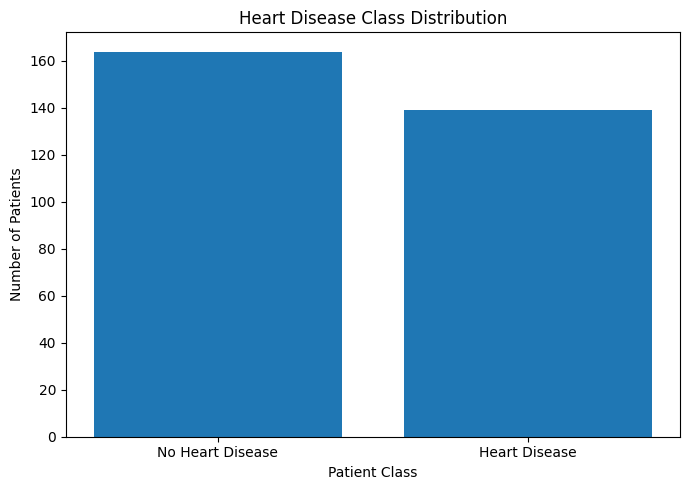

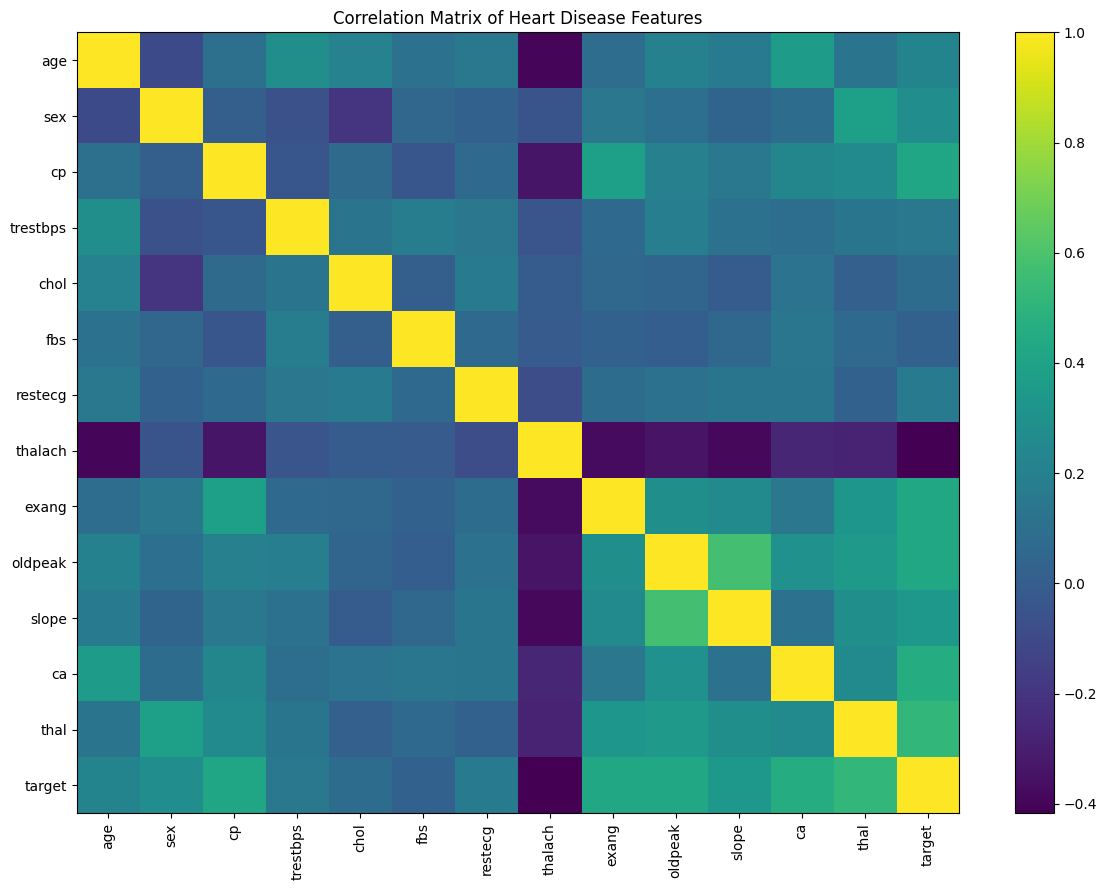



FEATURE AND TARGET INFORMATION
Number of input features: 13
Number of patients: 303

Training Samples   : 193
Validation Samples : 49
Testing Samples    : 61

Feature scaling completed.


CNN INPUT SHAPES
Training Shape: (193, 13, 1)
Validation Shape: (49, 13, 1)
Testing Shape: (61, 13, 1)


1D CNN MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 13, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,305 (165.25 KB)

 Trainable params: 41,857 (163.50 KB)

 Non-trainable params: 448 (1.75 KB)



STARTING 1D CNN TRAINING
Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.5855 - auc: 0.6815 - loss: 0.6541 - val_accuracy: 0.6531 - val_auc: 0.7517 - val_loss: 0.6818 - learning_rate: 0.0010
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7513 - auc: 0.8467 - loss: 0.5019 - val_accuracy: 0.7347 - val_auc: 0.8173 - val_loss: 0.6709 - learning_rate: 0.0010
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8083 - auc: 0.8704 - loss: 0.4636 - val_accuracy: 0.6531 - val_auc: 0.8249 - val_loss: 0.6643 - learning_rate: 0.0010
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7720 - auc: 0.8704 - loss: 0.4402 - val_accuracy: 0.7347 - val_auc: 0.8451 - val_loss: 0.6507 - learning_rate: 0.0010
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8705 - auc: 0.9240 - loss: 0.3712 - val_accuracy: 0.7959 - val_auc: 0.8569 - val_loss: 0.6347 - learning_rate: 0.0010
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc

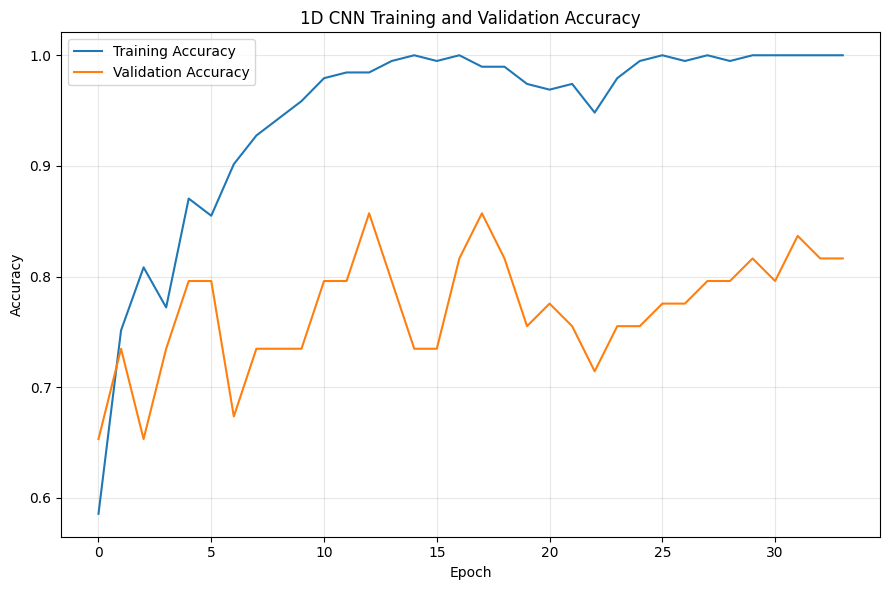

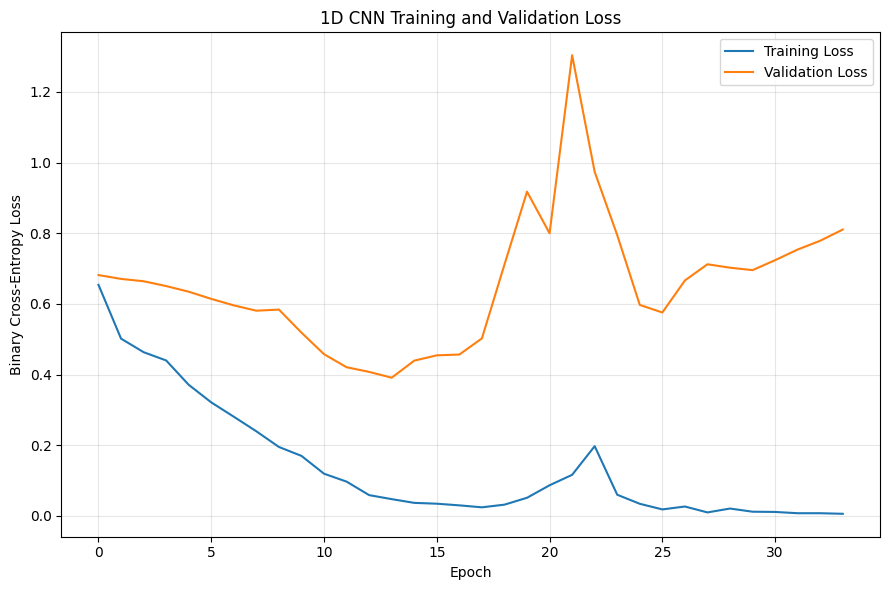

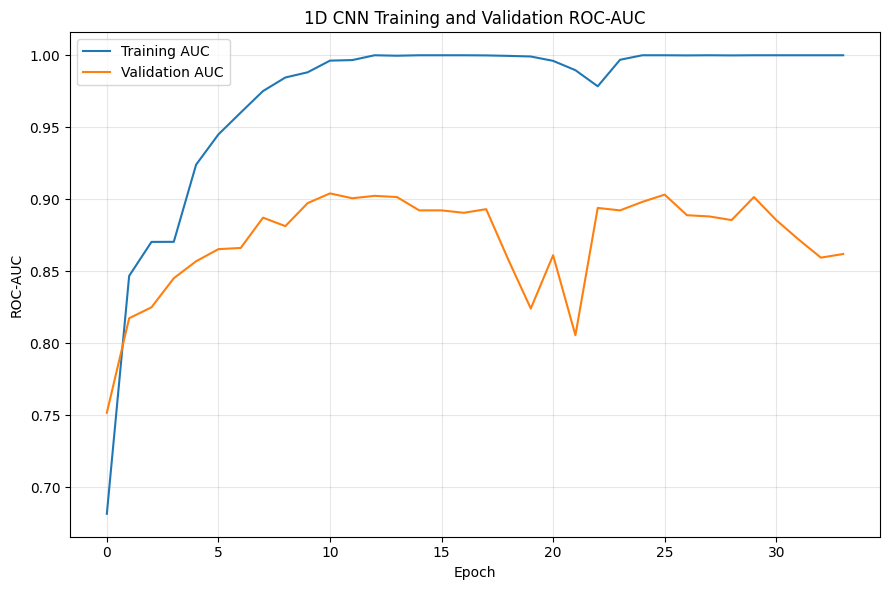



TEST SET EVALUATION

Test Loss     : 0.4365
Test Accuracy : 80.33%
Test AUC      : 0.8907


FINAL 1D CNN PERFORMANCE
Accuracy  : 80.33%
Precision : 73.53%
Recall    : 89.29%
F1 Score  : 80.65%
ROC-AUC   : 0.8907


CLASSIFICATION REPORT
                  precision    recall  f1-score   support

No Heart Disease       0.89      0.73      0.80        33
   Heart Disease       0.74      0.89      0.81        28

        accuracy                           0.80        61
       macro avg       0.81      0.81      0.80        61
    weighted avg       0.82      0.80      0.80        61


Confusion Matrix:
[[24  9]
 [ 3 25]]


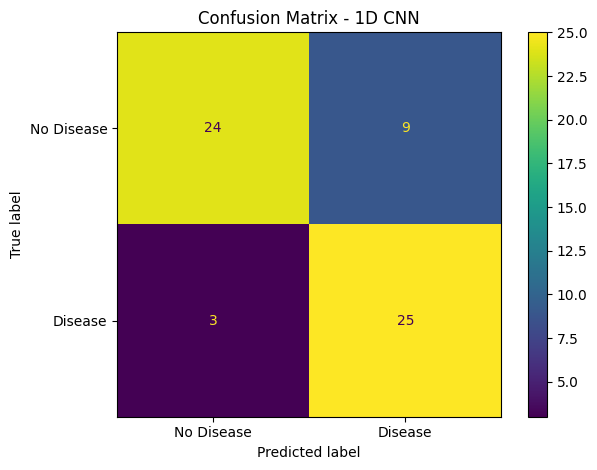

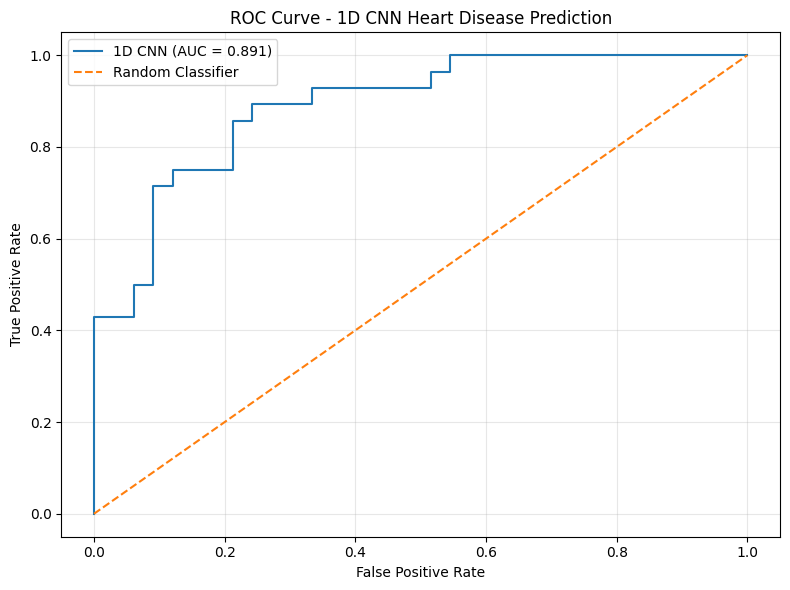



FINAL RESULT TABLE


,Metric,Score
0,Accuracy,0.8033
1,Precision,0.7353
2,Recall,0.8929
3,F1 Score,0.8065
4,ROC-AUC,0.8907




TRAINING VS TEST PERFORMANCE
Training Accuracy : 86.01%
Testing Accuracy  : 80.33%
Training ROC-AUC  : 0.9462
Testing ROC-AUC   : 0.8907


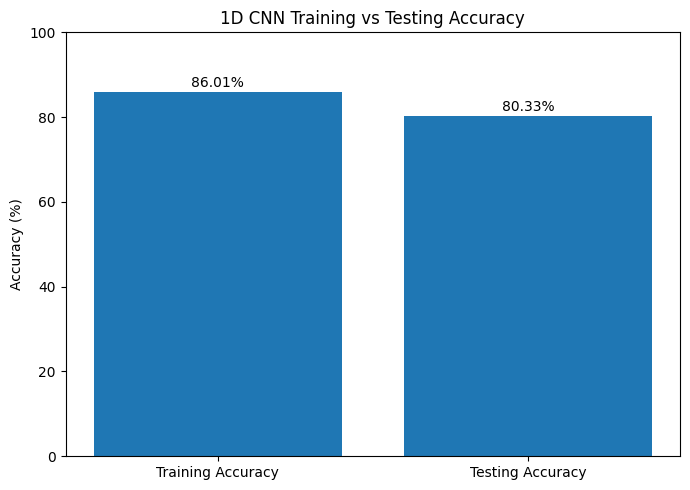



REFERENCE PAPER VS CURRENT IMPLEMENTATION
                Experiment  Accuracy (%)
Reference Paper - Training     97.000000
        Our CNN - Training     86.010363
 Reference Paper - Testing     96.000000
         Our CNN - Testing     80.327869


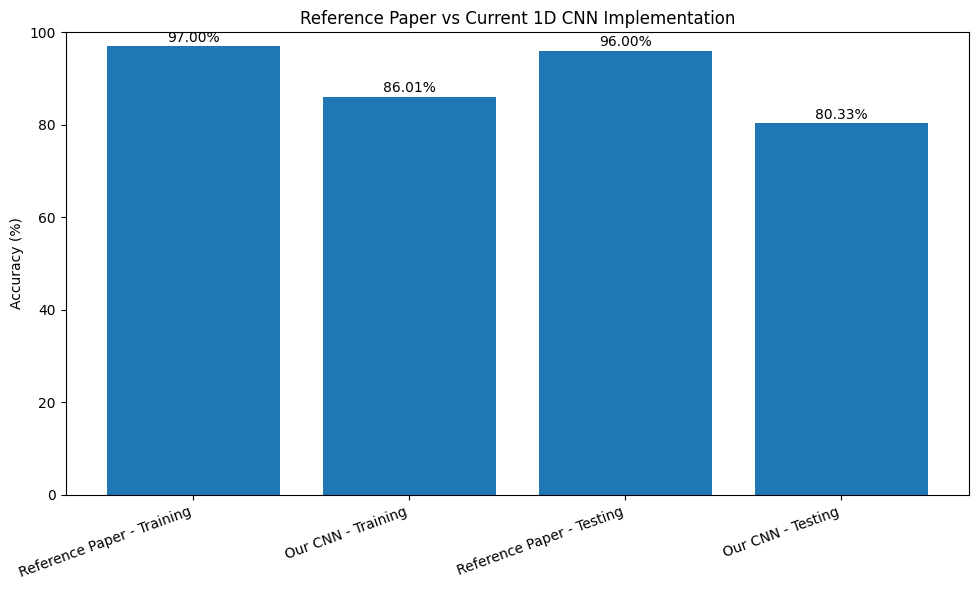



SAMPLE PATIENT PREDICTION
Predicted Disease Probability: 31.87%
Prediction: NO HEART DISEASE

This prediction is for academic demonstration only.


SAHITYA PAPER 3 - FINAL SUMMARY


Paper:
Novel Deep Learning Architecture for Heart Disease Prediction
using Convolutional Neural Network


Dataset Used in this Implementation:
UCI Cleveland Heart Disease Dataset


Problem:
Binary Classification

0 = No Heart Disease
1 = Heart Disease


Deep Learning Model:
1D Convolutional Neural Network


Architecture:
Input Clinical Features
        |
        v
Conv1D
        |
        v
Batch Normalization
        |
        v
MaxPooling1D
        |
        v
Conv1D
        |
        v
Conv1D
        |
        v
Global Average Pooling
        |
        v
Dense Layer
        |
        v
Dropout
        |
        v
Dense Layer
        |
        v
Sigmoid Output


Overfitting-Control Techniques:
-------------------------------
1. Train/validation/test separation
2. Batch Normalization
3. Dropout
4. Early 

In [3]:
# =====================================================================
# SAHITYA - IIT PROJECT
# PAPER 3
#
# Novel Deep Learning Architecture for Heart Disease Prediction
# using Convolutional Neural Network
#
# Practical implementation of a 1D-CNN for binary
# heart-disease classification.
#
# Dataset: UCI Cleveland Heart Disease Dataset
#
# Classes:
# 0 = No Heart Disease
# 1 = Heart Disease
# =====================================================================


# =====================================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================================

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)


# =====================================================================
# STEP 2: SET RANDOM SEEDS
# =====================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


print("=" * 80)
print("SAHITYA - PAPER 3")
print("HEART DISEASE PREDICTION USING 1D CNN")
print("=" * 80)


# =====================================================================
# STEP 3: LOAD UCI CLEVELAND HEART DISEASE DATASET
# =====================================================================

url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/heart-disease/"
    "processed.cleveland.data"
)


column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]


try:

    df = pd.read_csv(
        url,
        names=column_names,
        na_values="?"
    )

    print("\nDataset downloaded successfully from UCI.")

except Exception as e:

    print("\nCould not download UCI dataset.")
    print("Error:", e)

    print("\nUsing demonstration dataset instead.")

    from sklearn.datasets import make_classification

    X_demo, y_demo = make_classification(
        n_samples=303,
        n_features=13,
        n_informative=9,
        n_redundant=2,
        n_classes=2,
        random_state=SEED
    )

    df = pd.DataFrame(
        X_demo,
        columns=column_names[:-1]
    )

    df["target"] = y_demo


# =====================================================================
# STEP 4: DISPLAY DATASET INFORMATION
# =====================================================================

print("\n")
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


# =====================================================================
# STEP 5: CONVERT COLUMNS TO NUMERIC
# =====================================================================

for column in df.columns:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# =====================================================================
# STEP 6: HANDLE MISSING VALUES
# =====================================================================

for column in df.columns:

    if df[column].isnull().sum() > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(
            median_value
        )


print("\n")
print("=" * 80)
print("MISSING VALUES AFTER CLEANING")
print("=" * 80)

print(df.isnull().sum())


# =====================================================================
# STEP 7: CONVERT TARGET TO BINARY CLASSIFICATION
# =====================================================================
#
# Original Cleveland target:
#
# 0   = No heart disease
# 1-4 = Presence of heart disease
#
# We convert it into:
#
# 0 = Healthy / No Heart Disease
# 1 = Heart Disease
# =====================================================================

df["target"] = (
    df["target"] > 0
).astype(int)


print("\n")
print("=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print(df["target"].value_counts())

print("\nTarget Percentage:")

print(
    df["target"]
    .value_counts(normalize=True)
    * 100
)


# =====================================================================
# STEP 8: STATISTICAL SUMMARY
# =====================================================================

print("\n")
print("=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)

print(
    df.describe().round(2)
)


# =====================================================================
# STEP 9: CLASS DISTRIBUTION GRAPH
# =====================================================================

class_counts = (
    df["target"]
    .value_counts()
    .sort_index()
)


plt.figure(figsize=(7, 5))

plt.bar(
    ["No Heart Disease", "Heart Disease"],
    class_counts.values
)

plt.title(
    "Heart Disease Class Distribution"
)

plt.xlabel(
    "Patient Class"
)

plt.ylabel(
    "Number of Patients"
)

plt.tight_layout()

plt.show()


# =====================================================================
# STEP 10: CORRELATION MATRIX
# =====================================================================

correlation = df.corr(
    numeric_only=True
)


plt.figure(
    figsize=(12, 9)
)

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title(
    "Correlation Matrix of Heart Disease Features"
)

plt.tight_layout()

plt.show()


# =====================================================================
# STEP 11: SEPARATE FEATURES AND TARGET
# =====================================================================

X = df.drop(
    "target",
    axis=1
)

y = df["target"]


print("\n")
print("=" * 80)
print("FEATURE AND TARGET INFORMATION")
print("=" * 80)

print(
    "Number of input features:",
    X.shape[1]
)

print(
    "Number of patients:",
    X.shape[0]
)


# =====================================================================
# STEP 12: TRAIN / VALIDATION / TEST SPLIT
# =====================================================================
#
# First:
# 80% training + validation
# 20% testing
#
# Then:
# 80% of training portion = actual training
# 20% of training portion = validation
#
# Approximately:
# 64% Training
# 16% Validation
# 20% Testing
# =====================================================================


X_train_full, X_test, y_train_full, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=SEED,

    stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(

    X_train_full,
    y_train_full,

    test_size=0.20,

    random_state=SEED,

    stratify=y_train_full
)


print("\nTraining Samples   :", len(X_train))

print("Validation Samples :", len(X_val))

print("Testing Samples    :", len(X_test))


# =====================================================================
# STEP 13: FEATURE SCALING
# =====================================================================
#
# CNN training works better when numerical features are normalized.
#
# IMPORTANT:
# scaler is fitted ONLY on training data.
# =====================================================================

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)


print("\nFeature scaling completed.")


# =====================================================================
# STEP 14: RESHAPE DATA FOR 1D CNN
# =====================================================================
#
# Original shape:
#
# (patients, 13)
#
# CNN input shape:
#
# (patients, 13, 1)
#
# Each clinical feature is treated as one position in
# a one-dimensional feature sequence.
# =====================================================================


X_train_cnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)


X_val_cnn = X_val_scaled.reshape(
    X_val_scaled.shape[0],
    X_val_scaled.shape[1],
    1
)


X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)


print("\n")
print("=" * 80)
print("CNN INPUT SHAPES")
print("=" * 80)

print(
    "Training Shape:",
    X_train_cnn.shape
)

print(
    "Validation Shape:",
    X_val_cnn.shape
)

print(
    "Testing Shape:",
    X_test_cnn.shape
)


# =====================================================================
# STEP 15: BUILD THE 1D CNN MODEL
# =====================================================================
#
# Architecture:
#
# Input
#   ↓
# Conv1D
#   ↓
# Batch Normalization
#   ↓
# Max Pooling
#   ↓
# Conv1D
#   ↓
# Batch Normalization
#   ↓
# Global Average Pooling
#   ↓
# Dense
#   ↓
# Dropout
#   ↓
# Output
#
# Dropout + Batch Normalization help control overfitting.
# =====================================================================


model = Sequential([

    Input(
        shape=(
            X_train_cnn.shape[1],
            1
        )
    ),


    Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),


    BatchNormalization(),


    MaxPooling1D(
        pool_size=2
    ),


    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),


    BatchNormalization(),


    Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),


    BatchNormalization(),


    GlobalAveragePooling1D(),


    Dense(
        64,
        activation="relu"
    ),


    Dropout(
        0.40
    ),


    Dense(
        32,
        activation="relu"
    ),


    Dropout(
        0.30
    ),


    Dense(
        1,
        activation="sigmoid"
    )
])


# =====================================================================
# STEP 16: COMPILE MODEL
# =====================================================================

model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


print("\n")
print("=" * 80)
print("1D CNN MODEL ARCHITECTURE")
print("=" * 80)

model.summary()


# =====================================================================
# STEP 17: CALLBACKS
# =====================================================================
#
# EarlyStopping:
# Stops training if validation loss stops improving.
#
# ReduceLROnPlateau:
# Reduces learning rate when learning slows.
#
# These techniques help reduce overfitting.
# =====================================================================


early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True,

    verbose=1
)


reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=8,

    min_lr=0.00001,

    verbose=1
)


# =====================================================================
# STEP 18: TRAIN THE 1D CNN
# =====================================================================

print("\n")
print("=" * 80)
print("STARTING 1D CNN TRAINING")
print("=" * 80)


history = model.fit(

    X_train_cnn,

    y_train,

    validation_data=(
        X_val_cnn,
        y_val
    ),

    epochs=200,

    batch_size=16,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)


print("\nTraining completed.")


# =====================================================================
# STEP 19: TRAINING ACCURACY GRAPH
# =====================================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)


plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.title(
    "1D CNN Training and Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# =====================================================================
# STEP 20: TRAINING LOSS GRAPH
# =====================================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    history.history["loss"],
    label="Training Loss"
)


plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.title(
    "1D CNN Training and Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Binary Cross-Entropy Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# =====================================================================
# STEP 21: AUC TRAINING GRAPH
# =====================================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(
    history.history["auc"],
    label="Training AUC"
)


plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)


plt.title(
    "1D CNN Training and Validation ROC-AUC"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "ROC-AUC"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# =====================================================================
# STEP 22: EVALUATE CNN ON TEST DATA
# =====================================================================

print("\n")
print("=" * 80)
print("TEST SET EVALUATION")
print("=" * 80)


test_loss, keras_test_accuracy, keras_test_auc = model.evaluate(

    X_test_cnn,

    y_test,

    verbose=0
)


print(
    f"\nTest Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {keras_test_accuracy * 100:.2f}%"
)

print(
    f"Test AUC      : {keras_test_auc:.4f}"
)


# =====================================================================
# STEP 23: PREDICT TEST DATA
# =====================================================================

y_probability = model.predict(

    X_test_cnn,

    verbose=0

).ravel()


y_pred = (

    y_probability >= 0.50

).astype(int)


# =====================================================================
# STEP 24: CALCULATE ALL PERFORMANCE METRICS
# =====================================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)


recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)


f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


auc = roc_auc_score(
    y_test,
    y_probability
)


print("\n")
print("=" * 80)
print("FINAL 1D CNN PERFORMANCE")
print("=" * 80)


print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)

print(
    f"ROC-AUC   : {auc:.4f}"
)


# =====================================================================
# STEP 25: CLASSIFICATION REPORT
# =====================================================================

print("\n")
print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)


print(

    classification_report(

        y_test,

        y_pred,

        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ],

        zero_division=0
    )
)


# =====================================================================
# STEP 26: CONFUSION MATRIX
# =====================================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nConfusion Matrix:")

print(cm)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "No Disease",
        "Disease"
    ]
)


disp.plot()


plt.title(
    "Confusion Matrix - 1D CNN"
)

plt.tight_layout()

plt.show()


# =====================================================================
# STEP 27: ROC CURVE
# =====================================================================

fpr, tpr, thresholds = roc_curve(

    y_test,

    y_probability
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    fpr,

    tpr,

    label=f"1D CNN (AUC = {auc:.3f})"
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    label="Random Classifier"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - 1D CNN Heart Disease Prediction"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# =====================================================================
# STEP 28: FINAL RESULTS TABLE
# =====================================================================

results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})


print("\n")
print("=" * 80)
print("FINAL RESULT TABLE")
print("=" * 80)


display(

    results.style.format({

        "Score": "{:.4f}"

    })

)


# =====================================================================
# STEP 29: TRAINING PERFORMANCE
# =====================================================================

train_probability = model.predict(

    X_train_cnn,

    verbose=0

).ravel()


train_prediction = (

    train_probability >= 0.50

).astype(int)


train_accuracy = accuracy_score(

    y_train,

    train_prediction
)


train_auc = roc_auc_score(

    y_train,

    train_probability
)


print("\n")
print("=" * 80)
print("TRAINING VS TEST PERFORMANCE")
print("=" * 80)


print(
    f"Training Accuracy : {train_accuracy * 100:.2f}%"
)

print(
    f"Testing Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Training ROC-AUC  : {train_auc:.4f}"
)

print(
    f"Testing ROC-AUC   : {auc:.4f}"
)


# =====================================================================
# STEP 30: TRAINING VS TEST ACCURACY GRAPH
# =====================================================================

comparison_names = [

    "Training Accuracy",

    "Testing Accuracy"
]


comparison_values = [

    train_accuracy * 100,

    accuracy * 100
]


plt.figure(
    figsize=(7, 5)
)


plt.bar(

    comparison_names,

    comparison_values
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "1D CNN Training vs Testing Accuracy"
)


plt.ylim(
    0,
    100
)


for i, value in enumerate(comparison_values):

    plt.text(

        i,

        value + 1,

        f"{value:.2f}%",

        ha="center"
    )


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 31: COMPARE WITH REFERENCE PAPER RESULT
# =====================================================================
#
# According to the summary supplied for Sahitya's project:
#
# Reference training accuracy >97%
# Reference test accuracy ~96%
#
# These are reference values only.
# =====================================================================


reference_training_accuracy = 97.0

reference_test_accuracy = 96.0


comparison_df = pd.DataFrame({

    "Experiment": [

        "Reference Paper - Training",

        "Our CNN - Training",

        "Reference Paper - Testing",

        "Our CNN - Testing"
    ],

    "Accuracy (%)": [

        reference_training_accuracy,

        train_accuracy * 100,

        reference_test_accuracy,

        accuracy * 100
    ]
})


print("\n")
print("=" * 80)
print("REFERENCE PAPER VS CURRENT IMPLEMENTATION")
print("=" * 80)


print(
    comparison_df.to_string(
        index=False
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.bar(

    comparison_df["Experiment"],

    comparison_df["Accuracy (%)"]
)


plt.ylabel(
    "Accuracy (%)"
)


plt.title(
    "Reference Paper vs Current 1D CNN Implementation"
)


plt.xticks(
    rotation=20,
    ha="right"
)


plt.ylim(
    0,
    100
)


for i, value in enumerate(
    comparison_df["Accuracy (%)"]
):

    plt.text(

        i,

        value + 1,

        f"{value:.2f}%",

        ha="center"
    )


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 32: SAMPLE PATIENT PREDICTION
# =====================================================================
#
# Example only.
# NOT for medical diagnosis.
# =====================================================================


sample_patient = pd.DataFrame(

    [[

        58,     # age
        1,      # sex
        2,      # chest pain type
        140,    # resting blood pressure
        240,    # cholesterol
        0,      # fasting blood sugar
        1,      # resting ECG
        145,    # maximum heart rate
        0,      # exercise induced angina
        1.5,    # oldpeak
        1,      # slope
        0,      # number of major vessels
        3       # thal

    ]],

    columns=X.columns
)


# Apply SAME scaler used for training
sample_scaled = scaler.transform(

    sample_patient

)


# Convert to CNN shape
sample_cnn = sample_scaled.reshape(

    1,

    sample_scaled.shape[1],

    1
)


sample_probability = model.predict(

    sample_cnn,

    verbose=0

)[0][0]


sample_prediction = int(

    sample_probability >= 0.50

)


print("\n")
print("=" * 80)
print("SAMPLE PATIENT PREDICTION")
print("=" * 80)


print(

    f"Predicted Disease Probability: "
    f"{sample_probability * 100:.2f}%"

)


if sample_prediction == 0:

    print(
        "Prediction: NO HEART DISEASE"
    )

else:

    print(
        "Prediction: HEART DISEASE"
    )


print(
    "\nThis prediction is for academic demonstration only."
)


# =====================================================================
# STEP 33: PAPER 3 FINAL SUMMARY
# =====================================================================

print("\n")
print("=" * 80)
print("SAHITYA PAPER 3 - FINAL SUMMARY")
print("=" * 80)


print(f"""

Paper:
Novel Deep Learning Architecture for Heart Disease Prediction
using Convolutional Neural Network


Dataset Used in this Implementation:
UCI Cleveland Heart Disease Dataset


Problem:
Binary Classification

0 = No Heart Disease
1 = Heart Disease


Deep Learning Model:
1D Convolutional Neural Network


Architecture:
Input Clinical Features
        |
        v
Conv1D
        |
        v
Batch Normalization
        |
        v
MaxPooling1D
        |
        v
Conv1D
        |
        v
Conv1D
        |
        v
Global Average Pooling
        |
        v
Dense Layer
        |
        v
Dropout
        |
        v
Dense Layer
        |
        v
Sigmoid Output


Overfitting-Control Techniques:
-------------------------------
1. Train/validation/test separation
2. Batch Normalization
3. Dropout
4. Early Stopping
5. Learning-rate reduction


Evaluation Metrics:
-------------------
Accuracy
Precision
Recall
F1 Score
ROC-AUC
Confusion Matrix
ROC Curve


Current Implementation Results:
-------------------------------
Training Accuracy : {train_accuracy * 100:.2f}%

Testing Accuracy  : {accuracy * 100:.2f}%

Precision         : {precision * 100:.2f}%

Recall            : {recall * 100:.2f}%

F1 Score          : {f1 * 100:.2f}%

ROC-AUC           : {auc:.4f}


Reference Paper Context:
------------------------
The summary supplied for this IIT project reports more than
97% training accuracy and approximately 96% test accuracy for
the proposed 1D-CNN approach.

The accuracy obtained in this notebook does NOT need to be
exactly 96%.

Exact reproduction requires the same dataset, preprocessing,
data split, network architecture, hyperparameters and
experimental protocol used by the original authors.

The UCI Cleveland dataset is also small, so test accuracy can
change noticeably depending on the train/test split.

Therefore, the reference accuracy and the accuracy obtained
from this educational reproduction should be reported
separately.


IMPORTANT:
----------
This program is intended only for academic and research
demonstration.

It must not be used for actual medical diagnosis.

""")


print("=" * 80)
print("SAHITYA PAPER 3 EXECUTION COMPLETED SUCCESSFULLY")
print("=" * 80)

SAHITYA - PAPER 4
CARDIOVASCULAR DISEASE PREDICTION USING ML + DEEP LEARNING

Dataset downloaded successfully from UCI.


DATASET INFORMATION

Dataset Shape:
(303, 14)

First Five Rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  

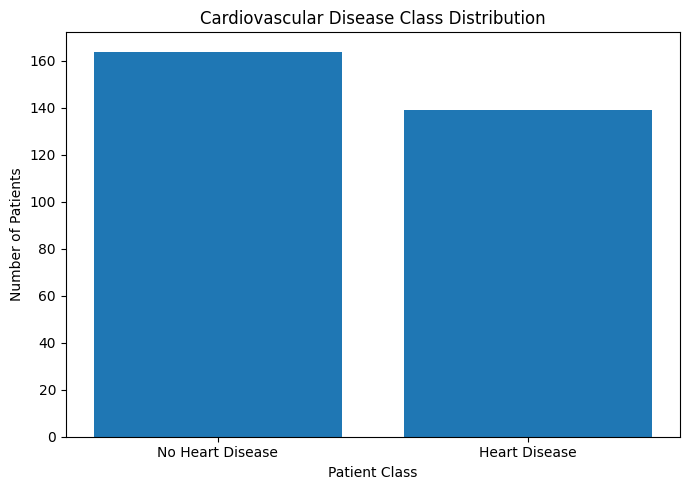

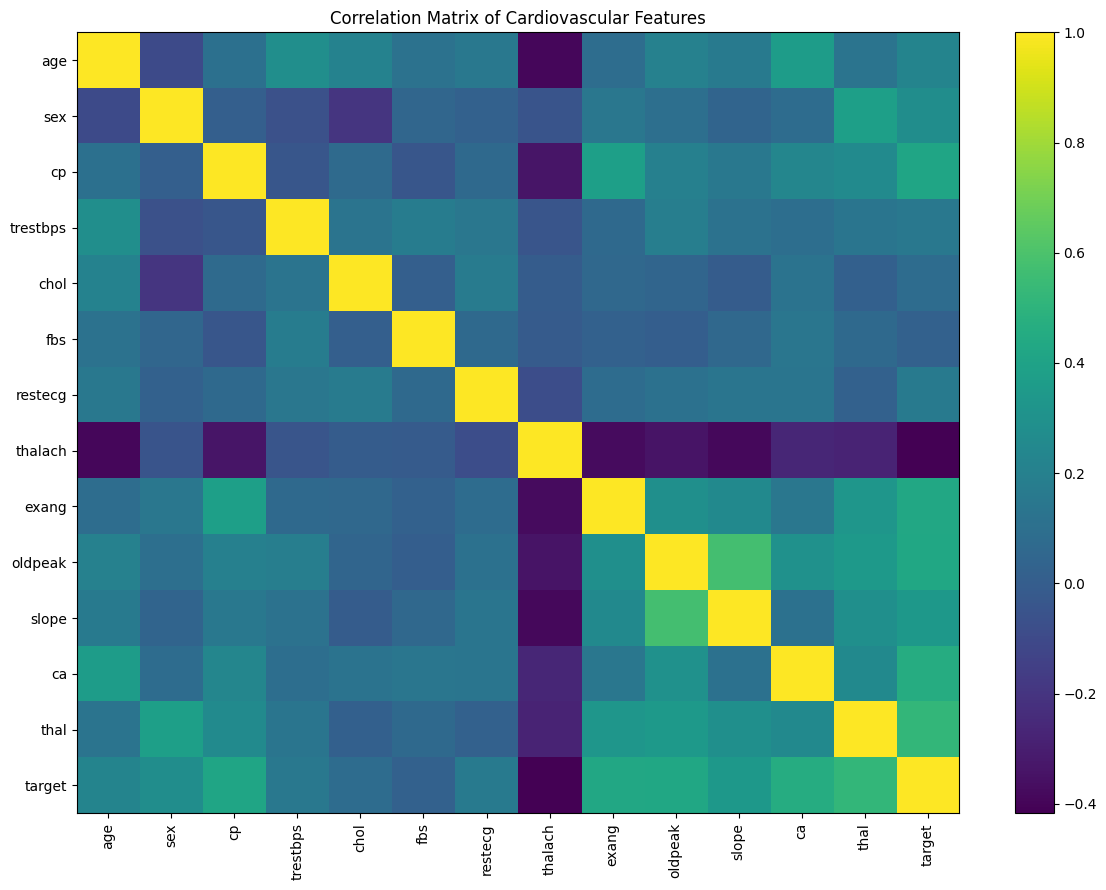



INPUT DATA
Number of Patients: 303
Number of Features: 13

Training Samples   : 193
Validation Samples : 49
Testing Samples    : 61

XGBoost loaded successfully.


5-FOLD CROSS-VALIDATION - MACHINE LEARNING

Evaluating: Logistic Regression
CV Accuracy : 83.16%
CV ROC-AUC  : 0.9116

Evaluating: SVM
CV Accuracy : 83.81%
CV ROC-AUC  : 0.8975

Evaluating: Random Forest
CV Accuracy : 84.82%
CV ROC-AUC  : 0.9089

Evaluating: Gradient Boosting
CV Accuracy : 81.49%
CV ROC-AUC  : 0.8992

Evaluating: XGBoost
CV Accuracy : 82.51%
CV ROC-AUC  : 0.8962


ML CROSS-VALIDATION RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8316,0.8304,0.7984,0.8126,0.9116
1,Random Forest,0.8482,0.8570,0.8056,0.8290,0.9089
2,Gradient Boosting,0.8149,0.8059,0.7831,0.7928,0.8992
3,SVM,0.8381,0.8526,0.7839,0.8153,0.8975
4,XGBoost,0.8251,0.8218,0.7981,0.8070,0.8962




MACHINE LEARNING MODEL TRAINING

Training: Logistic Regression
Accuracy : 86.89%
ROC-AUC  : 0.9513

Training: SVM
Accuracy : 85.25%
ROC-AUC  : 0.9437

Training: Random Forest
Accuracy : 91.80%
ROC-AUC  : 0.9583

Training: Gradient Boosting
Accuracy : 90.16%
ROC-AUC  : 0.9578

Training: XGBoost
Accuracy : 88.52%
ROC-AUC  : 0.9567


MACHINE LEARNING TEST RESULTS


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9583
1,Gradient Boosting,0.9016,0.8667,0.9286,0.8966,0.9578
2,XGBoost,0.8852,0.8182,0.9643,0.8852,0.9567
3,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
4,SVM,0.8525,0.8065,0.8929,0.8475,0.9437




BEST MACHINE LEARNING MODEL
Best ML Model: Random Forest
ROC-AUC: 0.9583

Deep-learning feature scaling completed.


DEEP LEARNING MODEL


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,545 (49.00 KB)

 Non-trainable params: 384 (1.50 KB)



DEEP LEARNING TRAINING
Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5078 - auc: 0.5700 - loss: 0.8805 - val_accuracy: 0.6939 - val_auc: 0.7391 - val_loss: 0.6411 - learning_rate: 0.0010
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6788 - auc: 0.7450 - loss: 0.6398 - val_accuracy: 0.7959 - val_auc: 0.8418 - val_loss: 0.5932 - learning_rate: 0.0010
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7409 - auc: 0.8028 - loss: 0.5477 - val_accuracy: 0.7959 - val_auc: 0.8729 - val_loss: 0.5571 - learning_rate: 0.0010
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7306 - auc: 0.8337 - loss: 0.5117 - val_accuracy: 0.8367 - val_auc: 0.8805 - val_loss: 0.5300 - learning_rate: 0.0010
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7772 - auc: 0.8768 - loss: 0.4251 - val_accuracy: 0.8367 - val_auc: 0.8847 - val_loss: 0.5083 - learning_rate: 0.0010
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accur

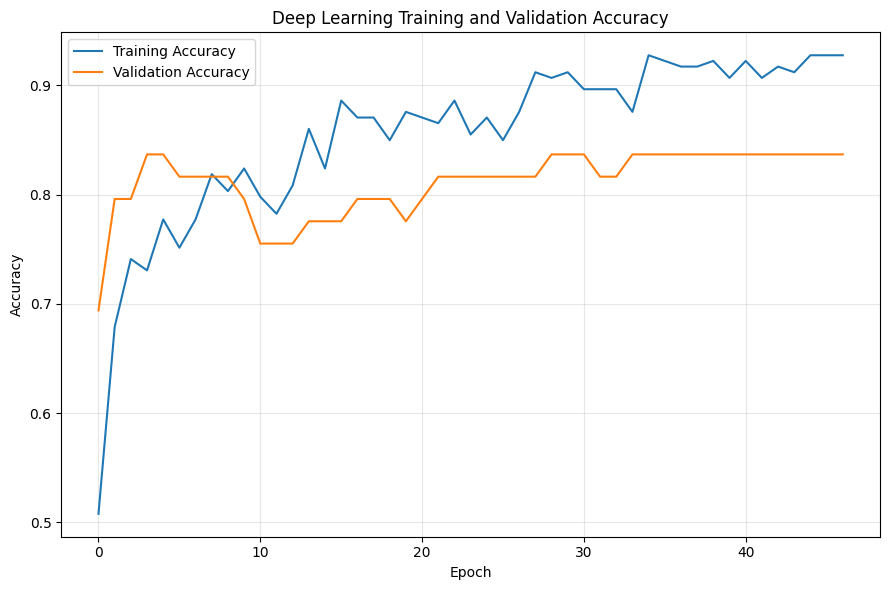

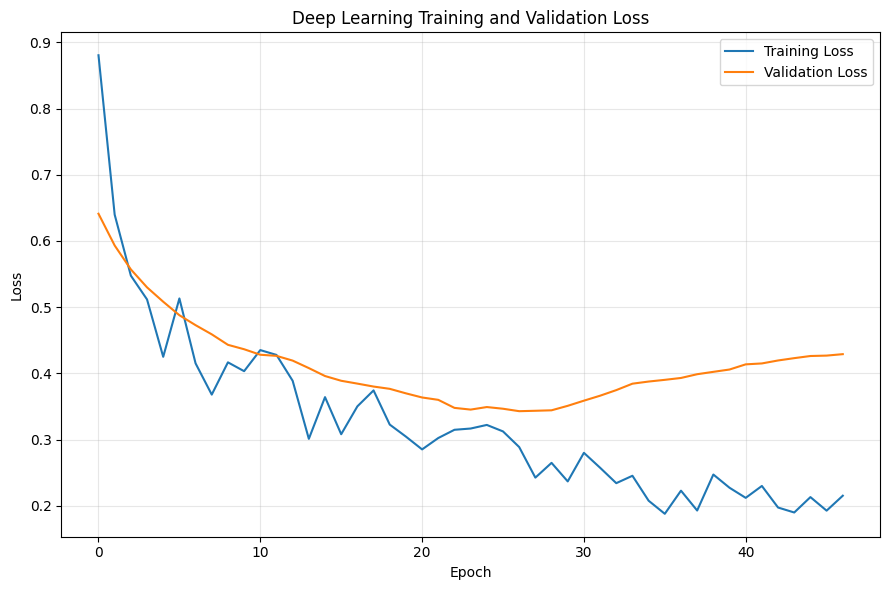



DEEP LEARNING PERFORMANCE
Accuracy  : 85.25%
Precision : 78.79%
Recall    : 92.86%
F1 Score  : 85.25%
ROC-AUC   : 0.9513

Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.93      0.79      0.85        33
   Heart Disease       0.79      0.93      0.85        28

        accuracy                           0.85        61
       macro avg       0.86      0.86      0.85        61
    weighted avg       0.86      0.85      0.85        61



COMBINED ML + DEEP LEARNING PERFORMANCE
Machine Learning Component: Random Forest
Deep Learning Component: Deep Neural Network

Accuracy  : 88.52%
Precision : 81.82%
Recall    : 96.43%
F1 Score  : 88.52%
ROC-AUC   : 0.9567


COMBINED MODEL CLASSIFICATION REPORT
                  precision    recall  f1-score   support

No Heart Disease       0.96      0.82      0.89        33
   Heart Disease       0.82      0.96      0.89        28

        accuracy                           0.89        61
    

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9180,0.8710,0.9643,0.9153,0.9583
1,Gradient Boosting,0.9016,0.8667,0.9286,0.8966,0.9578
2,XGBoost,0.8852,0.8182,0.9643,0.8852,0.9567
3,Combined ML + DL,0.8852,0.8182,0.9643,0.8852,0.9567
4,Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
5,Deep Neural Network,0.8525,0.7879,0.9286,0.8525,0.9513
6,SVM,0.8525,0.8065,0.8929,0.8475,0.9437


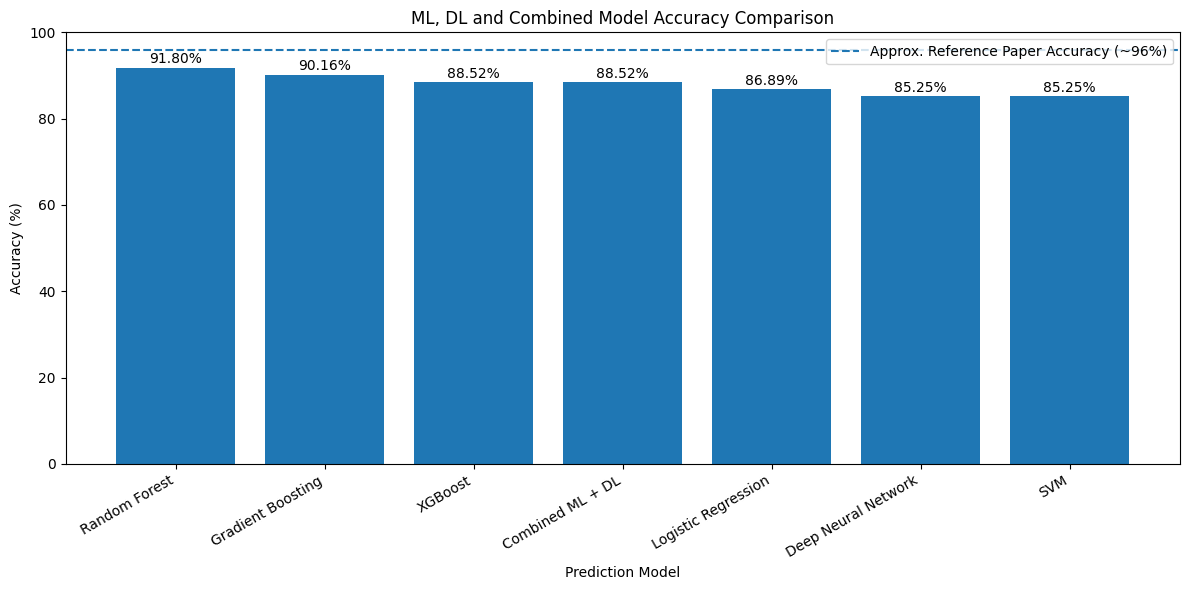

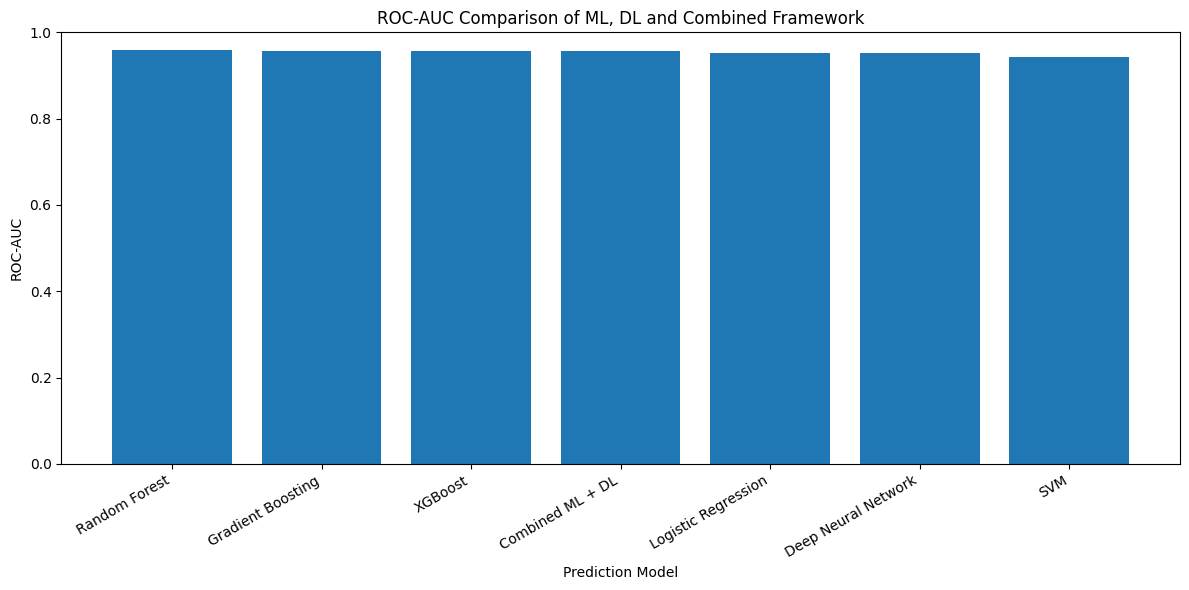

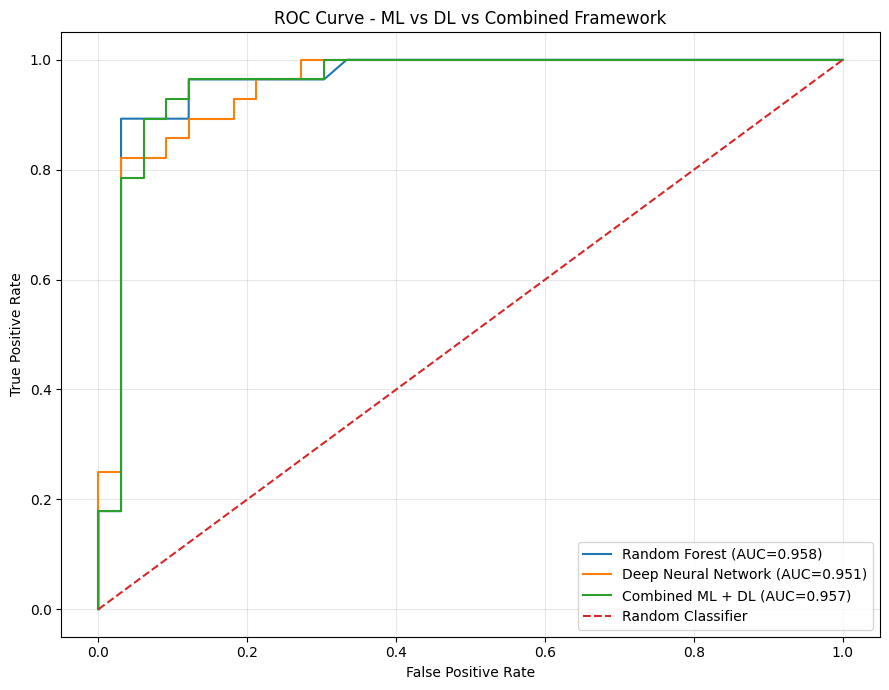


Combined Model Confusion Matrix:
[[27  6]
 [ 1 27]]


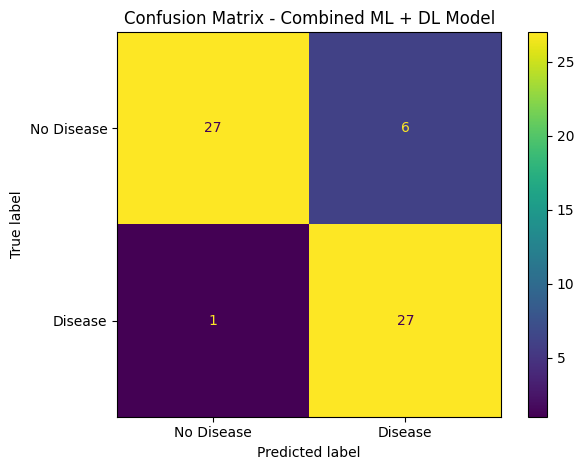



CLINICAL FEATURE IMPORTANCE
 Feature  Importance
    thal    0.130714
 thalach    0.120942
      cp    0.118695
      ca    0.109750
     age    0.096474
 oldpeak    0.091358
    chol    0.084957
trestbps    0.078302
   exang    0.050887
   slope    0.044035
     sex    0.040286
 restecg    0.022454
     fbs    0.011147


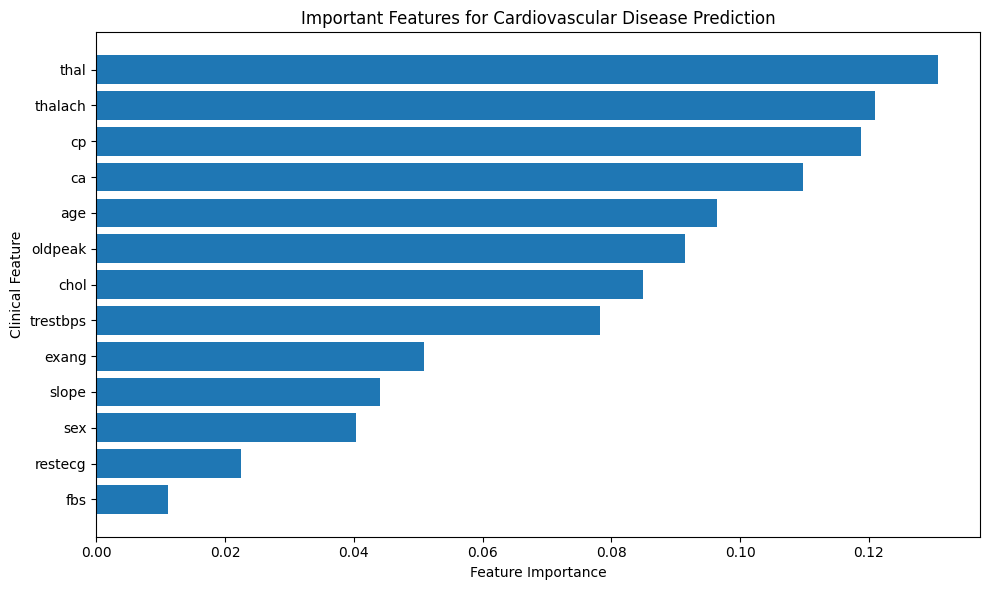



REFERENCE PAPER COMPARISON
               System  Accuracy (%)
      Reference Paper     96.000000
Best Machine Learning     91.803279
  Deep Neural Network     85.245902
     Combined ML + DL     88.524590


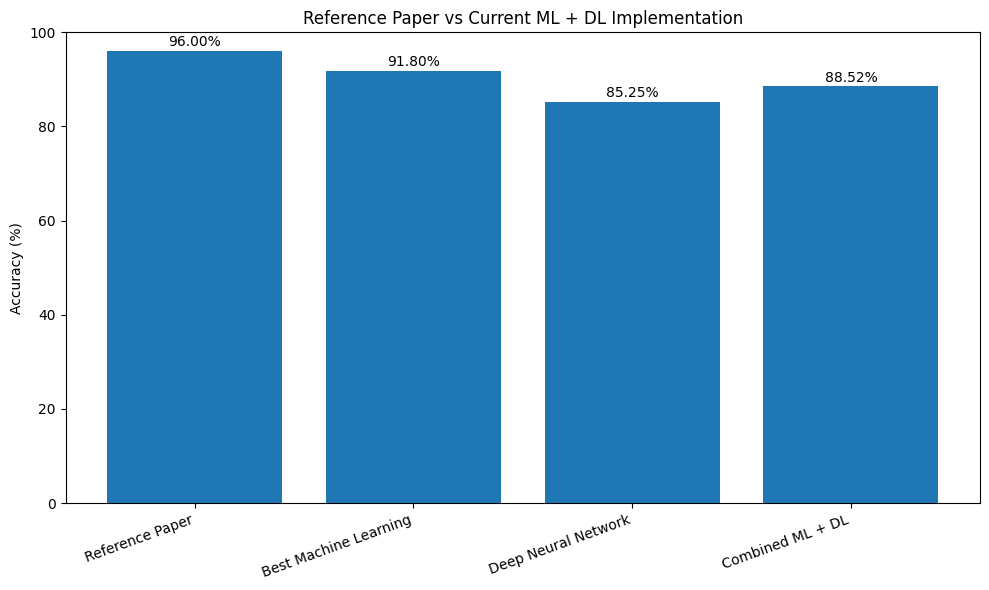



SAMPLE PATIENT - COMBINED ML + DL PREDICTION
ML Probability : 23.67%
DL Probability : 19.79%
Combined Probability : 21.73%

Prediction: NO HEART DISEASE

This prediction is for academic demonstration only.


BEST OVERALL MODEL
Model: Random Forest
Accuracy: 91.80%
Precision: 87.10%
Recall: 96.43%
F1 Score: 91.53%
ROC-AUC: 0.9583


SAHITYA PAPER 4 - FINAL SUMMARY


Paper:
Cardiovascular Diseases Prediction by Machine Learning
Incorporation with Deep Learning


Dataset Used:
UCI Cleveland Heart Disease Dataset


Problem:
Binary Cardiovascular Disease Classification

0 = No Heart Disease
1 = Heart Disease


MACHINE LEARNING MODELS:
------------------------
1. Logistic Regression
2. Support Vector Machine
3. Random Forest
4. Gradient Boosting
5. XGBoost (when available)


DEEP LEARNING MODEL:
--------------------
Deep Neural Network

Architecture:

Clinical Features
       |
       v
Dense 128
       |
       v
Batch Normalization
       |
       v
Dropout
       |
       v
Dense 64
    

In [4]:
# =====================================================================
# SAHITYA - IIT PROJECT
# PAPER 4
#
# Cardiovascular Diseases Prediction by Machine Learning
# Incorporation with Deep Learning
#
# Practical ML + DL Cardiovascular Disease Prediction Framework
#
# Dataset:
# UCI Cleveland Heart Disease Dataset
#
# Models:
# 1. Logistic Regression
# 2. Support Vector Machine
# 3. Random Forest
# 4. Gradient Boosting
# 5. XGBoost (if available)
# 6. Deep Neural Network
# 7. Combined ML + DL Ensemble
#
# Classes:
# 0 = No Heart Disease
# 1 = Heart Disease
# =====================================================================


# =====================================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================================

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)


# =====================================================================
# STEP 2: SET RANDOM SEED
# =====================================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


print("=" * 80)
print("SAHITYA - PAPER 4")
print("CARDIOVASCULAR DISEASE PREDICTION USING ML + DEEP LEARNING")
print("=" * 80)


# =====================================================================
# STEP 3: LOAD UCI HEART DISEASE DATASET
# =====================================================================

url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/heart-disease/"
    "processed.cleveland.data"
)


column_names = [

    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]


try:

    df = pd.read_csv(
        url,
        names=column_names,
        na_values="?"
    )

    print("\nDataset downloaded successfully from UCI.")


except Exception as e:

    print("\nDataset download failed.")

    print("Error:", e)

    print("\nUsing demonstration dataset instead.")

    from sklearn.datasets import make_classification

    X_demo, y_demo = make_classification(

        n_samples=303,

        n_features=13,

        n_informative=9,

        n_redundant=2,

        n_classes=2,

        random_state=SEED
    )

    df = pd.DataFrame(

        X_demo,

        columns=column_names[:-1]
    )

    df["target"] = y_demo


# =====================================================================
# STEP 4: DATASET INFORMATION
# =====================================================================

print("\n")
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)


print("\nDataset Shape:")

print(df.shape)


print("\nFirst Five Rows:")

print(df.head())


print("\nDataset Information:")

df.info()


print("\nMissing Values:")

print(df.isnull().sum())


# =====================================================================
# STEP 5: CONVERT COLUMNS TO NUMERIC
# =====================================================================

for column in df.columns:

    df[column] = pd.to_numeric(

        df[column],

        errors="coerce"
    )


# =====================================================================
# STEP 6: HANDLE MISSING VALUES
# =====================================================================

for column in df.columns:

    if df[column].isnull().sum() > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(

            median_value
        )


print("\n")
print("=" * 80)
print("MISSING VALUES AFTER CLEANING")
print("=" * 80)

print(df.isnull().sum())


# =====================================================================
# STEP 7: CONVERT TARGET TO BINARY CLASSIFICATION
# =====================================================================
#
# Original Cleveland dataset:
#
# 0     = No heart disease
# 1-4   = Presence of heart disease
#
# Converted to:
#
# 0 = No Heart Disease
# 1 = Heart Disease
# =====================================================================


df["target"] = (

    df["target"] > 0

).astype(int)


print("\n")
print("=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)


print(df["target"].value_counts())


print("\nTarget Percentage:")


print(

    df["target"]
    .value_counts(normalize=True)
    * 100

)


# =====================================================================
# STEP 8: STATISTICAL SUMMARY
# =====================================================================

print("\n")
print("=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)


print(

    df.describe().round(2)

)


# =====================================================================
# STEP 9: TARGET DISTRIBUTION GRAPH
# =====================================================================

class_counts = (

    df["target"]
    .value_counts()
    .sort_index()

)


plt.figure(

    figsize=(7, 5)

)


plt.bar(

    ["No Heart Disease", "Heart Disease"],

    class_counts.values
)


plt.xlabel(

    "Patient Class"

)


plt.ylabel(

    "Number of Patients"

)


plt.title(

    "Cardiovascular Disease Class Distribution"

)


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 10: CORRELATION MATRIX
# =====================================================================

correlation = df.corr(

    numeric_only=True

)


plt.figure(

    figsize=(12, 9)

)


plt.imshow(

    correlation,

    aspect="auto"
)


plt.colorbar()


plt.xticks(

    range(len(correlation.columns)),

    correlation.columns,

    rotation=90
)


plt.yticks(

    range(len(correlation.columns)),

    correlation.columns
)


plt.title(

    "Correlation Matrix of Cardiovascular Features"

)


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 11: SEPARATE INPUT FEATURES AND TARGET
# =====================================================================

X = df.drop(

    "target",

    axis=1
)


y = df["target"]


print("\n")
print("=" * 80)
print("INPUT DATA")
print("=" * 80)


print(

    "Number of Patients:",

    X.shape[0]
)


print(

    "Number of Features:",

    X.shape[1]
)


# =====================================================================
# STEP 12: TRAIN-TEST SPLIT
# =====================================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=SEED,

    stratify=y
)


# =====================================================================
# STEP 13: CREATE TRAINING AND VALIDATION DATA
# =====================================================================

X_train, X_val, y_train, y_val = train_test_split(

    X_train_full,

    y_train_full,

    test_size=0.20,

    random_state=SEED,

    stratify=y_train_full
)


print("\nTraining Samples   :", len(X_train))

print("Validation Samples :", len(X_val))

print("Testing Samples    :", len(X_test))


# =====================================================================
# STEP 14: DEFINE MACHINE LEARNING MODELS
# =====================================================================

ml_models = {


    # -----------------------------------------------------------------
    # LOGISTIC REGRESSION
    # -----------------------------------------------------------------

    "Logistic Regression":

        Pipeline([

            (
                "scaler",

                StandardScaler()
            ),

            (
                "model",

                LogisticRegression(

                    max_iter=2000,

                    random_state=SEED
                )
            )
        ]),


    # -----------------------------------------------------------------
    # SUPPORT VECTOR MACHINE
    # -----------------------------------------------------------------

    "SVM":

        Pipeline([

            (
                "scaler",

                StandardScaler()
            ),

            (
                "model",

                SVC(

                    kernel="rbf",

                    probability=True,

                    random_state=SEED
                )
            )
        ]),


    # -----------------------------------------------------------------
    # RANDOM FOREST
    # -----------------------------------------------------------------

    "Random Forest":

        RandomForestClassifier(

            n_estimators=300,

            random_state=SEED,

            class_weight="balanced"
        ),


    # -----------------------------------------------------------------
    # GRADIENT BOOSTING
    # -----------------------------------------------------------------

    "Gradient Boosting":

        GradientBoostingClassifier(

            n_estimators=150,

            learning_rate=0.05,

            max_depth=2,

            random_state=SEED
        )
}


# =====================================================================
# STEP 15: ADD XGBOOST IF AVAILABLE
# =====================================================================

try:

    from xgboost import XGBClassifier


    ml_models["XGBoost"] = XGBClassifier(

        n_estimators=200,

        max_depth=3,

        learning_rate=0.05,

        subsample=0.9,

        colsample_bytree=0.9,

        eval_metric="logloss",

        random_state=SEED
    )


    print("\nXGBoost loaded successfully.")


except Exception:

    print(

        "\nXGBoost unavailable. "
        "Remaining models will continue normally."
    )


# =====================================================================
# STEP 16: 5-FOLD CROSS-VALIDATION FOR ML MODELS
# =====================================================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=SEED
)


scoring = {

    "accuracy": "accuracy",

    "precision": "precision",

    "recall": "recall",

    "f1": "f1",

    "roc_auc": "roc_auc"
}


cv_results = []


print("\n")
print("=" * 80)
print("5-FOLD CROSS-VALIDATION - MACHINE LEARNING")
print("=" * 80)


for model_name, model in ml_models.items():


    print("\nEvaluating:", model_name)


    scores = cross_validate(

        model,

        X,

        y,

        cv=cv,

        scoring=scoring,

        n_jobs=-1
    )


    result = {

        "Model": model_name,

        "Accuracy":
            np.mean(scores["test_accuracy"]),

        "Precision":
            np.mean(scores["test_precision"]),

        "Recall":
            np.mean(scores["test_recall"]),

        "F1 Score":
            np.mean(scores["test_f1"]),

        "ROC-AUC":
            np.mean(scores["test_roc_auc"])
    }


    cv_results.append(result)


    print(

        f"CV Accuracy : "
        f"{result['Accuracy'] * 100:.2f}%"
    )


    print(

        f"CV ROC-AUC  : "
        f"{result['ROC-AUC']:.4f}"
    )


# =====================================================================
# STEP 17: DISPLAY ML CROSS-VALIDATION RESULTS
# =====================================================================

cv_df = pd.DataFrame(

    cv_results

)


cv_df = cv_df.sort_values(

    by="ROC-AUC",

    ascending=False

).reset_index(drop=True)


print("\n")
print("=" * 90)
print("ML CROSS-VALIDATION RESULTS")
print("=" * 90)


display(

    cv_df.style.format({

        "Accuracy": "{:.4f}",

        "Precision": "{:.4f}",

        "Recall": "{:.4f}",

        "F1 Score": "{:.4f}",

        "ROC-AUC": "{:.4f}"
    })

)


# =====================================================================
# STEP 18: TRAIN ML MODELS
# =====================================================================

ml_results = []

ml_probabilities = {}

ml_predictions = {}


print("\n")
print("=" * 80)
print("MACHINE LEARNING MODEL TRAINING")
print("=" * 80)


for model_name, model in ml_models.items():


    print("\nTraining:", model_name)


    # Train model using complete train+validation portion
    model.fit(

        X_train_full,

        y_train_full
    )


    # Predict test classes
    y_pred = model.predict(

        X_test
    )


    # Predict probabilities
    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(

            X_test

        )[:, 1]


    else:

        y_prob = model.decision_function(

            X_test
        )


    ml_predictions[model_name] = y_pred

    ml_probabilities[model_name] = y_prob


    accuracy = accuracy_score(

        y_test,

        y_pred
    )


    precision = precision_score(

        y_test,

        y_pred,

        zero_division=0
    )


    recall = recall_score(

        y_test,

        y_pred,

        zero_division=0
    )


    f1 = f1_score(

        y_test,

        y_pred,

        zero_division=0
    )


    auc = roc_auc_score(

        y_test,

        y_prob
    )


    ml_results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC-AUC": auc
    })


    print(

        f"Accuracy : {accuracy * 100:.2f}%"
    )


    print(

        f"ROC-AUC  : {auc:.4f}"
    )


# =====================================================================
# STEP 19: ML RESULTS TABLE
# =====================================================================

ml_results_df = pd.DataFrame(

    ml_results

)


ml_results_df = ml_results_df.sort_values(

    by="ROC-AUC",

    ascending=False

).reset_index(drop=True)


print("\n")
print("=" * 90)
print("MACHINE LEARNING TEST RESULTS")
print("=" * 90)


display(

    ml_results_df.style.format({

        "Accuracy": "{:.4f}",

        "Precision": "{:.4f}",

        "Recall": "{:.4f}",

        "F1 Score": "{:.4f}",

        "ROC-AUC": "{:.4f}"
    })

)


# =====================================================================
# STEP 20: IDENTIFY BEST ML MODEL
# =====================================================================

best_ml_name = (

    ml_results_df.iloc[0]["Model"]

)


best_ml_model = ml_models[

    best_ml_name

]


best_ml_probability = ml_probabilities[

    best_ml_name

]


print("\n")
print("=" * 80)
print("BEST MACHINE LEARNING MODEL")
print("=" * 80)


print(

    "Best ML Model:",

    best_ml_name
)


print(

    f"ROC-AUC: "
    f"{ml_results_df.iloc[0]['ROC-AUC']:.4f}"
)


# =====================================================================
# STEP 21: SCALE DATA FOR DEEP LEARNING
# =====================================================================
#
# IMPORTANT:
# The scaler is fitted ONLY on the DL training set.
# Validation/test information is not used to fit the scaler.
# =====================================================================

dl_scaler = StandardScaler()


X_train_scaled = dl_scaler.fit_transform(

    X_train
)


X_val_scaled = dl_scaler.transform(

    X_val
)


X_test_scaled = dl_scaler.transform(

    X_test
)


print("\nDeep-learning feature scaling completed.")


# =====================================================================
# STEP 22: BUILD DEEP NEURAL NETWORK
# =====================================================================
#
# Deep Learning Architecture:
#
# Input
#   |
# Dense 128
#   |
# Batch Normalization
#   |
# Dropout
#   |
# Dense 64
#   |
# Batch Normalization
#   |
# Dropout
#   |
# Dense 32
#   |
# Dropout
#   |
# Sigmoid Output
# =====================================================================


dl_model = Sequential([


    Input(

        shape=(X_train_scaled.shape[1],)

    ),


    Dense(

        128,

        activation="relu"
    ),


    BatchNormalization(),


    Dropout(

        0.40
    ),


    Dense(

        64,

        activation="relu"
    ),


    BatchNormalization(),


    Dropout(

        0.30
    ),


    Dense(

        32,

        activation="relu"
    ),


    Dropout(

        0.20
    ),


    Dense(

        1,

        activation="sigmoid"
    )
])


# =====================================================================
# STEP 23: COMPILE DEEP LEARNING MODEL
# =====================================================================

dl_model.compile(

    optimizer=Adam(

        learning_rate=0.001

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.AUC(

            name="auc"

        )
    ]
)


print("\n")
print("=" * 80)
print("DEEP LEARNING MODEL")
print("=" * 80)


dl_model.summary()


# =====================================================================
# STEP 24: CREATE CALLBACKS
# =====================================================================

early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=20,

    restore_best_weights=True,

    verbose=1
)


reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=8,

    min_lr=0.00001,

    verbose=1
)


# =====================================================================
# STEP 25: TRAIN DEEP LEARNING MODEL
# =====================================================================

print("\n")
print("=" * 80)
print("DEEP LEARNING TRAINING")
print("=" * 80)


history = dl_model.fit(

    X_train_scaled,

    y_train,

    validation_data=(

        X_val_scaled,

        y_val
    ),

    epochs=200,

    batch_size=16,

    callbacks=[

        early_stopping,

        reduce_lr
    ],

    verbose=1
)


# =====================================================================
# STEP 26: TRAINING ACCURACY GRAPH
# =====================================================================

plt.figure(

    figsize=(9, 6)

)


plt.plot(

    history.history["accuracy"],

    label="Training Accuracy"
)


plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy"
)


plt.xlabel(

    "Epoch"
)


plt.ylabel(

    "Accuracy"
)


plt.title(

    "Deep Learning Training and Validation Accuracy"
)


plt.legend()


plt.grid(

    alpha=0.3
)


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 27: TRAINING LOSS GRAPH
# =====================================================================

plt.figure(

    figsize=(9, 6)

)


plt.plot(

    history.history["loss"],

    label="Training Loss"
)


plt.plot(

    history.history["val_loss"],

    label="Validation Loss"
)


plt.xlabel(

    "Epoch"
)


plt.ylabel(

    "Loss"
)


plt.title(

    "Deep Learning Training and Validation Loss"
)


plt.legend()


plt.grid(

    alpha=0.3
)


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 28: DEEP LEARNING PREDICTION
# =====================================================================

dl_probability = dl_model.predict(

    X_test_scaled,

    verbose=0

).ravel()


dl_prediction = (

    dl_probability >= 0.50

).astype(int)


# =====================================================================
# STEP 29: DEEP LEARNING METRICS
# =====================================================================

dl_accuracy = accuracy_score(

    y_test,

    dl_prediction
)


dl_precision = precision_score(

    y_test,

    dl_prediction,

    zero_division=0
)


dl_recall = recall_score(

    y_test,

    dl_prediction,

    zero_division=0
)


dl_f1 = f1_score(

    y_test,

    dl_prediction,

    zero_division=0
)


dl_auc = roc_auc_score(

    y_test,

    dl_probability
)


print("\n")
print("=" * 80)
print("DEEP LEARNING PERFORMANCE")
print("=" * 80)


print(

    f"Accuracy  : {dl_accuracy * 100:.2f}%"
)


print(

    f"Precision : {dl_precision * 100:.2f}%"
)


print(

    f"Recall    : {dl_recall * 100:.2f}%"
)


print(

    f"F1 Score  : {dl_f1 * 100:.2f}%"
)


print(

    f"ROC-AUC   : {dl_auc:.4f}"
)


print("\nClassification Report:")


print(

    classification_report(

        y_test,

        dl_prediction,

        target_names=[

            "No Heart Disease",

            "Heart Disease"
        ],

        zero_division=0
    )

)


# =====================================================================
# STEP 30: CREATE COMBINED ML + DL MODEL
# =====================================================================
#
# This is the key section for Paper 4.
#
# Best ML model probability
#              +
# Deep Learning probability
#              |
#              v
# Weighted probability fusion
#              |
#              v
# Final CVD prediction
#
# Equal weighting is used:
#
# 50% ML
# 50% DL
# =====================================================================


combined_probability = (

    0.50 * best_ml_probability

    +

    0.50 * dl_probability
)


combined_prediction = (

    combined_probability >= 0.50

).astype(int)


# =====================================================================
# STEP 31: COMBINED ML + DL PERFORMANCE
# =====================================================================

combined_accuracy = accuracy_score(

    y_test,

    combined_prediction
)


combined_precision = precision_score(

    y_test,

    combined_prediction,

    zero_division=0
)


combined_recall = recall_score(

    y_test,

    combined_prediction,

    zero_division=0
)


combined_f1 = f1_score(

    y_test,

    combined_prediction,

    zero_division=0
)


combined_auc = roc_auc_score(

    y_test,

    combined_probability
)


print("\n")
print("=" * 80)
print("COMBINED ML + DEEP LEARNING PERFORMANCE")
print("=" * 80)


print(

    "Machine Learning Component:",

    best_ml_name
)


print(

    "Deep Learning Component: Deep Neural Network"
)


print(

    f"\nAccuracy  : "
    f"{combined_accuracy * 100:.2f}%"
)


print(

    f"Precision : "
    f"{combined_precision * 100:.2f}%"
)


print(

    f"Recall    : "
    f"{combined_recall * 100:.2f}%"
)


print(

    f"F1 Score  : "
    f"{combined_f1 * 100:.2f}%"
)


print(

    f"ROC-AUC   : "
    f"{combined_auc:.4f}"
)


# =====================================================================
# STEP 32: CLASSIFICATION REPORT FOR COMBINED MODEL
# =====================================================================

print("\n")
print("=" * 80)
print("COMBINED MODEL CLASSIFICATION REPORT")
print("=" * 80)


print(

    classification_report(

        y_test,

        combined_prediction,

        target_names=[

            "No Heart Disease",

            "Heart Disease"
        ],

        zero_division=0
    )

)


# =====================================================================
# STEP 33: FINAL COMPARISON TABLE
# =====================================================================

all_results = ml_results.copy()


all_results.append({

    "Model":
        "Deep Neural Network",

    "Accuracy":
        dl_accuracy,

    "Precision":
        dl_precision,

    "Recall":
        dl_recall,

    "F1 Score":
        dl_f1,

    "ROC-AUC":
        dl_auc
})


all_results.append({

    "Model":
        "Combined ML + DL",

    "Accuracy":
        combined_accuracy,

    "Precision":
        combined_precision,

    "Recall":
        combined_recall,

    "F1 Score":
        combined_f1,

    "ROC-AUC":
        combined_auc
})


final_results_df = pd.DataFrame(

    all_results

)


final_results_df = final_results_df.sort_values(

    by="ROC-AUC",

    ascending=False

).reset_index(drop=True)


print("\n")
print("=" * 100)
print("FINAL ML + DL MODEL COMPARISON")
print("=" * 100)


display(

    final_results_df.style.format({

        "Accuracy": "{:.4f}",

        "Precision": "{:.4f}",

        "Recall": "{:.4f}",

        "F1 Score": "{:.4f}",

        "ROC-AUC": "{:.4f}"
    })

)


# =====================================================================
# STEP 34: ACCURACY COMPARISON GRAPH
# =====================================================================

plt.figure(

    figsize=(12, 6)

)


plt.bar(

    final_results_df["Model"],

    final_results_df["Accuracy"] * 100
)


plt.axhline(

    y=96,

    linestyle="--",

    label="Approx. Reference Paper Accuracy (~96%)"
)


plt.xlabel(

    "Prediction Model"

)


plt.ylabel(

    "Accuracy (%)"
)


plt.title(

    "ML, DL and Combined Model Accuracy Comparison"
)


plt.xticks(

    rotation=30,

    ha="right"
)


plt.ylim(

    0,

    100
)


plt.legend()


for i, value in enumerate(

    final_results_df["Accuracy"] * 100

):


    plt.text(

        i,

        value + 1,

        f"{value:.2f}%",

        ha="center"
    )


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 35: ROC-AUC COMPARISON GRAPH
# =====================================================================

plt.figure(

    figsize=(12, 6)

)


plt.bar(

    final_results_df["Model"],

    final_results_df["ROC-AUC"]
)


plt.xlabel(

    "Prediction Model"
)


plt.ylabel(

    "ROC-AUC"
)


plt.title(

    "ROC-AUC Comparison of ML, DL and Combined Framework"
)


plt.xticks(

    rotation=30,

    ha="right"
)


plt.ylim(

    0,

    1
)


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 36: ROC CURVE - BEST ML VS DL VS COMBINED
# =====================================================================

plt.figure(

    figsize=(9, 7)

)


# Best ML
fpr_ml, tpr_ml, _ = roc_curve(

    y_test,

    best_ml_probability
)


plt.plot(

    fpr_ml,

    tpr_ml,

    label=(

        f"{best_ml_name} "
        f"(AUC={roc_auc_score(y_test, best_ml_probability):.3f})"
    )
)


# Deep Learning
fpr_dl, tpr_dl, _ = roc_curve(

    y_test,

    dl_probability
)


plt.plot(

    fpr_dl,

    tpr_dl,

    label=(

        f"Deep Neural Network "
        f"(AUC={dl_auc:.3f})"
    )
)


# Combined
fpr_combined, tpr_combined, _ = roc_curve(

    y_test,

    combined_probability
)


plt.plot(

    fpr_combined,

    tpr_combined,

    label=(

        f"Combined ML + DL "
        f"(AUC={combined_auc:.3f})"
    )
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    label="Random Classifier"
)


plt.xlabel(

    "False Positive Rate"
)


plt.ylabel(

    "True Positive Rate"
)


plt.title(

    "ROC Curve - ML vs DL vs Combined Framework"
)


plt.legend()


plt.grid(

    alpha=0.3
)


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 37: COMBINED MODEL CONFUSION MATRIX
# =====================================================================

cm = confusion_matrix(

    y_test,

    combined_prediction
)


print("\nCombined Model Confusion Matrix:")

print(cm)


disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "No Disease",

        "Disease"
    ]
)


disp.plot()


plt.title(

    "Confusion Matrix - Combined ML + DL Model"
)


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 38: RANDOM FOREST FEATURE IMPORTANCE
# =====================================================================

rf_model = ml_models["Random Forest"]


feature_importance = pd.DataFrame({

    "Feature":
        X.columns,

    "Importance":
        rf_model.feature_importances_
})


feature_importance = (

    feature_importance

    .sort_values(

        by="Importance",

        ascending=False
    )

)


print("\n")
print("=" * 80)
print("CLINICAL FEATURE IMPORTANCE")
print("=" * 80)


print(

    feature_importance.to_string(

        index=False

    )

)


plt.figure(

    figsize=(10, 6)

)


plt.barh(

    feature_importance["Feature"][::-1],

    feature_importance["Importance"][::-1]
)


plt.xlabel(

    "Feature Importance"
)


plt.ylabel(

    "Clinical Feature"
)


plt.title(

    "Important Features for Cardiovascular Disease Prediction"
)


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 39: REFERENCE PAPER COMPARISON
# =====================================================================

reference_accuracy = 96.0


reference_comparison = pd.DataFrame({

    "System": [

        "Reference Paper",

        "Best Machine Learning",

        "Deep Neural Network",

        "Combined ML + DL"
    ],

    "Accuracy (%)": [

        reference_accuracy,

        ml_results_df.iloc[0]["Accuracy"] * 100,

        dl_accuracy * 100,

        combined_accuracy * 100
    ]
})


print("\n")
print("=" * 80)
print("REFERENCE PAPER COMPARISON")
print("=" * 80)


print(

    reference_comparison.to_string(

        index=False

    )

)


plt.figure(

    figsize=(10, 6)

)


plt.bar(

    reference_comparison["System"],

    reference_comparison["Accuracy (%)"]
)


plt.ylabel(

    "Accuracy (%)"
)


plt.title(

    "Reference Paper vs Current ML + DL Implementation"
)


plt.xticks(

    rotation=20,

    ha="right"
)


plt.ylim(

    0,

    100
)


for i, value in enumerate(

    reference_comparison["Accuracy (%)"]

):


    plt.text(

        i,

        value + 1,

        f"{value:.2f}%",

        ha="center"
    )


plt.tight_layout()

plt.show()


# =====================================================================
# STEP 40: SAMPLE PATIENT PREDICTION
# =====================================================================
#
# Example only.
# This must NOT be used for medical diagnosis.
# =====================================================================

sample_patient = pd.DataFrame(

    [[

        58,     # age

        1,      # sex

        2,      # chest pain type

        140,    # resting blood pressure

        240,    # cholesterol

        0,      # fasting blood sugar

        1,      # resting ECG

        145,    # maximum heart rate

        0,      # exercise-induced angina

        1.5,    # oldpeak

        1,      # slope

        0,      # number of major vessels

        3       # thal

    ]],

    columns=X.columns
)


# =====================================================================
# STEP 41: ML PREDICTION FOR SAMPLE PATIENT
# =====================================================================

if hasattr(

    best_ml_model,

    "predict_proba"

):


    sample_ml_probability = (

        best_ml_model.predict_proba(

            sample_patient

        )[0][1]

    )


else:


    sample_ml_score = (

        best_ml_model.decision_function(

            sample_patient

        )[0]

    )


    sample_ml_probability = (

        1 /

        (

            1 +

            np.exp(

                -sample_ml_score

            )

        )

    )


# =====================================================================
# STEP 42: DL PREDICTION FOR SAMPLE PATIENT
# =====================================================================

sample_scaled = dl_scaler.transform(

    sample_patient
)


sample_dl_probability = (

    dl_model.predict(

        sample_scaled,

        verbose=0

    )[0][0]

)


# =====================================================================
# STEP 43: COMBINE ML + DL SAMPLE PREDICTION
# =====================================================================

sample_combined_probability = (

    0.50 * sample_ml_probability

    +

    0.50 * sample_dl_probability
)


sample_prediction = int(

    sample_combined_probability >= 0.50

)


print("\n")
print("=" * 80)
print("SAMPLE PATIENT - COMBINED ML + DL PREDICTION")
print("=" * 80)


print(

    f"ML Probability : "
    f"{sample_ml_probability * 100:.2f}%"
)


print(

    f"DL Probability : "
    f"{sample_dl_probability * 100:.2f}%"
)


print(

    f"Combined Probability : "
    f"{sample_combined_probability * 100:.2f}%"
)


if sample_prediction == 0:

    print(

        "\nPrediction: NO HEART DISEASE"

    )

else:

    print(

        "\nPrediction: HEART DISEASE"

    )


print(

    "\nThis prediction is for academic demonstration only."
)


# =====================================================================
# STEP 44: FINAL MODEL
# =====================================================================

best_final_row = (

    final_results_df.iloc[0]

)


print("\n")
print("=" * 80)
print("BEST OVERALL MODEL")
print("=" * 80)


print(

    "Model:",

    best_final_row["Model"]
)


print(

    f"Accuracy: "
    f"{best_final_row['Accuracy'] * 100:.2f}%"
)


print(

    f"Precision: "
    f"{best_final_row['Precision'] * 100:.2f}%"
)


print(

    f"Recall: "
    f"{best_final_row['Recall'] * 100:.2f}%"
)


print(

    f"F1 Score: "
    f"{best_final_row['F1 Score'] * 100:.2f}%"
)


print(

    f"ROC-AUC: "
    f"{best_final_row['ROC-AUC']:.4f}"
)


# =====================================================================
# STEP 45: FINAL PROJECT SUMMARY
# =====================================================================

print("\n")
print("=" * 80)
print("SAHITYA PAPER 4 - FINAL SUMMARY")
print("=" * 80)


print(f"""

Paper:
Cardiovascular Diseases Prediction by Machine Learning
Incorporation with Deep Learning


Dataset Used:
UCI Cleveland Heart Disease Dataset


Problem:
Binary Cardiovascular Disease Classification

0 = No Heart Disease
1 = Heart Disease


MACHINE LEARNING MODELS:
------------------------
1. Logistic Regression
2. Support Vector Machine
3. Random Forest
4. Gradient Boosting
5. XGBoost (when available)


DEEP LEARNING MODEL:
--------------------
Deep Neural Network

Architecture:

Clinical Features
       |
       v
Dense 128
       |
       v
Batch Normalization
       |
       v
Dropout
       |
       v
Dense 64
       |
       v
Batch Normalization
       |
       v
Dropout
       |
       v
Dense 32
       |
       v
Sigmoid Output


COMBINED FRAMEWORK:
-------------------

          Clinical Dataset
                 |
          Data Preprocessing
                 |
        ---------------------
        |                   |
        v                   v
 Machine Learning      Deep Learning
        |                   |
        v                   v
 Best ML Probability   DL Probability
        |                   |
        -----------+---------
                   |
                   v
         Probability Fusion
                   |
                   v
      Final CVD Classification


Current Combined Model Results:
-------------------------------

Accuracy  : {combined_accuracy * 100:.2f}%

Precision : {combined_precision * 100:.2f}%

Recall    : {combined_recall * 100:.2f}%

F1 Score  : {combined_f1 * 100:.2f}%

ROC-AUC   : {combined_auc:.4f}


Reference Paper Context:
------------------------
The project summary provided for this paper reports
approximately 96% prediction accuracy and emphasizes
the integration of machine-learning and deep-learning
methods for cardiovascular disease prediction.

The current implementation compares multiple ML models,
trains a deep neural network and combines ML and DL
probabilities into a final predictive framework.

The result obtained here does NOT have to be exactly 96%.

Exact reproduction of the published result requires the
authors' exact datasets, preprocessing procedures,
feature-selection strategy, train/test division,
hyperparameters and experimental setup.


IMPORTANT:
----------
This implementation is intended for educational and
research demonstration only.

It must NOT be used for actual medical diagnosis.

""")


print("=" * 80)
print("SAHITYA PAPER 4 EXECUTION COMPLETED SUCCESSFULLY")
print("=" * 80)